In [1]:
import os
import csv
import sys
import time
import json
import typing as t
import requests
import pandas as pd
import numpy as np
from typing import Dict, Iterable, Optional
from pathlib import Path
import mplfinance as mpf
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller
import statsmodels.api as sm
import scipy.stats as stats
from utils import *
from datetime import date, datetime, timezone
from scipy.stats import ks_2samp, f_oneway, levene, probplot

# **************
# **  Config  **
# **************
OUTPUT = "../work/data"
DATETIME_COL = "datetime"


Using cuda (NVIDIA GeForce RTX 2060)


In [ ]:
# carga datos
df = pd.read_csv(OUTPUT + f"/_etf.csv", parse_dates=[DATETIME_COL])


In [ ]:
# check basico
df.info()
display(df.describe())
display(df.describe().T)

#| Column Name         | Description                                                                  | DataType | Categorical/Continuo |
#| ------------------- | ---------------------------------------------------------------------------- | -------- | ------ |
#| `datetime`          | Timestamp of the observation in UTC time; used as time-series index.         | datetime64(ms) | Temporal |
#| `date_hour`         | Hour of the day extracted from `datetime_utc`; useful for intraday patterns. | int | categorical |
#| `date_day`          | Day of the month extracted for seasonal effects.                             | int | categorical |
#| `date_month`        | Month of the year for capturing monthly trends or seasonality.               | int | categorical |
#| `close`             | Asset closing price at each timestamp.                                       | float | continuous |
#| `volume`            | Trading volume in units or value.                                            | int | continuous |
#| `log_volume`        | Log of Trading volume           .                                            | float | continuous |
#| `ema10`             | 10-period Exponential Moving Average.                                        | float | continuous |
#| `ema50`             | 50-period Exponential Moving Average.                                        | float | continuous |
#| `ema20`             | 200-period Exponential Moving Average.                                       | float | continuous |
#| `ema_ratio`         |                                                                              | float | continuous |
#| `ema_spread`        |                                                                              | float | continuous |
#| `macd`              | MACD indicator (EMA12 - EMA26) used for trend following.                     | float | continuous |
#| `macd_signal`       | Signal line (EMA of MACD), used for generating buy/sell signals.             | float | continuous |
#| `macd_histogram`    | Difference between MACD and signal line; reflects momentum.                  | float | continuous |
#| `volatility_24h`    | Historical volatility over a 24-hour rolling window.                         | float | continuous |
#| `obv`               | On-Balance Volume; volume-based momentum indicator.                          | float | continuous |
#| `sofr`              | Secured Overnight Financing Rate; macroeconomic interest rate reference.     | float | continuous |
#| `vix`               | Volatility Index (fear index); reflects market risk sentiment.               | float | continuous |
#| `log_return`        | Logarithmic return of the asset's price.                                     | float | continuous |
#| `target_log_return` | Target variable; log return shifted into the future for forecasting.         | float | continuous |




<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34980 entries, 0 to 34979
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   datetime           34980 non-null  datetime64[ns]
 1   date_hour          34980 non-null  int64         
 2   date_day           34980 non-null  int64         
 3   date_month         34980 non-null  int64         
 4   close              34980 non-null  float64       
 5   volume             34980 non-null  int64         
 6   log_volume         34980 non-null  float64       
 7   ema10              34980 non-null  float64       
 8   ema50              34980 non-null  float64       
 9   ema200             34980 non-null  float64       
 10  ema_ratio          34980 non-null  float64       
 11  ema_spread         34980 non-null  float64       
 12  macd               34980 non-null  float64       
 13  macd_signal        34980 non-null  float64       
 14  macd_h

,datetime,date_hour,date_day,date_month,close,volume,log_volume,ema10,ema50,ema200,ema_ratio,ema_spread,macd,macd_signal,macd_histogram,volatility_24h,obv,sofr,vix,log_return,target_log_return
count,34980,34980.000000,34980.000000,34980.000000,34980.000000,3.498000e+04,34980.000000,34980.000000,34980.000000,34980.000000,34980.000000,34980.000000,34980.000000,34980.000000,34980.000000,34980.000000,3.498000e+04,34980.000000,34980.000000,34980.000000,34980.000000
mean,2023-01-03 04:30:00,11.501715,2.997570,6.535878,225.865856,1.342927e+06,6.041474,225.807598,225.368774,223.573656,1.001855,0.438824,0.143645,0.154425,-0.010780,0.001989,8.947819e+08,0.029669,19.321863,0.000045,0.000045
min,2021-01-04 11:00:00,0.000000,0.000000,1.000000,96.139396,0.000000e+00,0.000000,96.730305,97.649090,98.568561,0.964325,-10.270581,-4.834248,-4.351937,-1.629931,0.000000,-9.868536e+07,0.000100,11.860000,-0.009177,-0.009177
25%,2022-01-03 19:45:00,6.000000,1.000000,4.000000,145.906801,0.000000e+00,0.000000,146.044657,146.138788,146.304212,0.995111,-0.971947,-0.460838,-0.423100,-0.160476,0.000460,3.026696e+08,0.000500,15.100000,0.000000,0.000000
50%,2023-01-03 04:30:00,12.000000,3.000000,7.000000,176.543769,0.000000e+00,0.000000,176.420712,177.252451,175.145205,1.002696,0.537240,0.173533,0.177390,-0.004437,0.002201,6.846133e+08,0.043000,18.390000,0.000000,0.000000
75%,2024-01-02 13:15:00,18.000000,5.000000,10.000000,281.631445,3.667590e+05,12.812463,281.770819,280.976904,278.992619,1.008795,1.786973,0.747304,0.727136,0.140919,0.003047,1.362072e+09,0.053000,22.210000,0.000000,0.000000
max,2024-12-31 22:00:00,23.000000,6.000000,12.000000,492.628301,2.622953e+07,17.082396,491.330497,488.334695,481.127675,1.035934,9.549089,4.697680,4.251106,1.563333,0.006197,2.045517e+09,0.054000,38.570000,0.009243,0.009243
std,NaN,6.922013,2.000492,3.442245,106.965028,2.827167e+06,6.765356,106.936031,106.668677,105.399548,0.010129,2.260061,0.995110,0.935791,0.281683,0.001421,6.575286e+08,0.023125,5.262916,0.002453,0.002453


,count,mean,min,25%,50%,75%,max,std
datetime,34980,2023-01-03 04:30:00,2021-01-04 11:00:00,2022-01-03 19:45:00,2023-01-03 04:30:00,2024-01-02 13:15:00,2024-12-31 22:00:00,NaN
date_hour,34980.0,11.501715,0.0,6.0,12.0,18.0,23.0,6.922013
date_day,34980.0,2.99757,0.0,1.0,3.0,5.0,6.0,2.000492
date_month,34980.0,6.535878,1.0,4.0,7.0,10.0,12.0,3.442245
close,34980.0,225.865856,96.139396,145.906801,176.543769,281.631445,492.628301,106.965028
volume,34980.0,1342927.433676,0.0,0.0,0.0,366759.0,26229529.0,2827167.084634
log_volume,34980.0,6.041474,0.0,0.0,0.0,12.812463,17.082396,6.765356
ema10,34980.0,225.807598,96.730305,146.044657,176.420712,281.770819,491.330497,106.936031
ema50,34980.0,225.368774,97.64909,146.138788,177.252451,280.976904,488.334695,106.668677
ema200,34980.0,223.573656,98.568561,146.304212,175.145205,278.992619,481.127675,105.399548


In [ ]:
# Datetime Parsing 



In [ ]:
# Datetime sorted chronologcally
is_sorted = df['datetime'].is_monotonic_increasing
print(is_sorted)


True


In [ ]:
# Missing values analysis
print("\nMissing values per column:\n", df.isna().sum())



Missing values per column:
 datetime             0
date_hour            0
date_day             0
date_month           0
close                0
volume               0
log_volume           0
ema10                0
ema50                0
ema200               0
ema_ratio            0
ema_spread           0
macd                 0
macd_signal          0
macd_histogram       0
volatility_24h       0
obv                  0
sofr                 0
vix                  0
log_return           0
target_log_return    0
dtype: int64


In [ ]:
# Duplicate rows
print("\nDuplicate rows:", df.duplicated().sum())



Duplicate rows: 0


In [ ]:
# Ensure hourly frequency (adjust if daily)
df_indexed = df.set_index(DATETIME_COL)
expected = pd.date_range(df_indexed.index.min(), df_indexed.index.max(), freq="h")
missing_timestamps = expected.difference(df_indexed.index)
print(missing_timestamps)
print("\nMissing timestamps:", len(missing_timestamps))


DatetimeIndex([], dtype='datetime64[ns]', freq='h')

Missing timestamps: 0


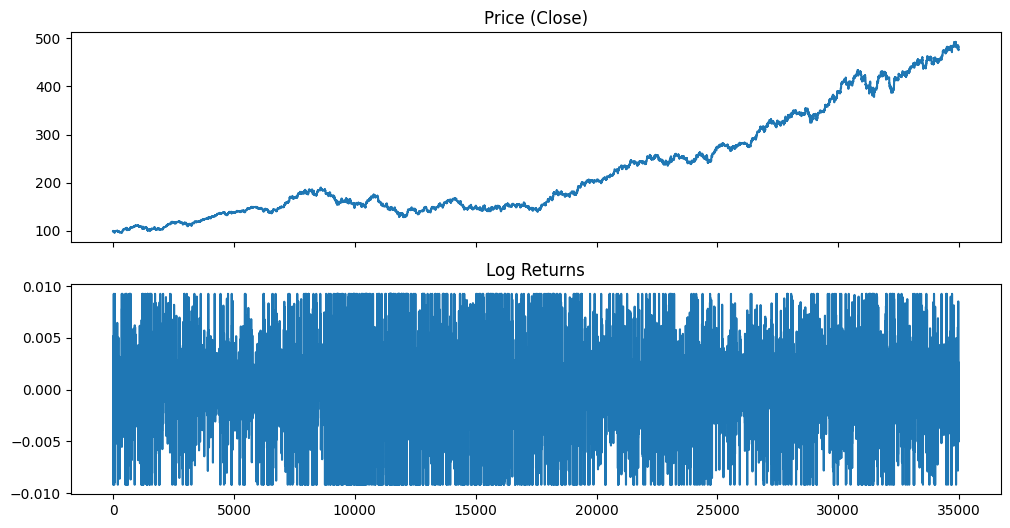

Close: ADF Statistic: 1.4744553165609438
Close: p-value: 0.9974274707261331
log-return: ADF Statistic: -34.389580651422825
log-return: p-value: 0.0


In [ ]:
# returns are stationary, while prices are not
fig, axes = plt.subplots(2, 1, figsize=(12,6), sharex=True)

df['close'].plot(ax=axes[0], title="Price (Close)")
df['log_return'].plot(ax=axes[1], title="Log Returns")
plt.show()

# Supongamos que 'serie' es un pandas Series con tus datos
resultado = adfuller(df['close'])
print('Close: ADF Statistic:', resultado[0])
print('Close: p-value:', resultado[1])
resultado = adfuller(df['log_return'])
print('log-return: ADF Statistic:', resultado[0])
print('log-return: p-value:', resultado[1])





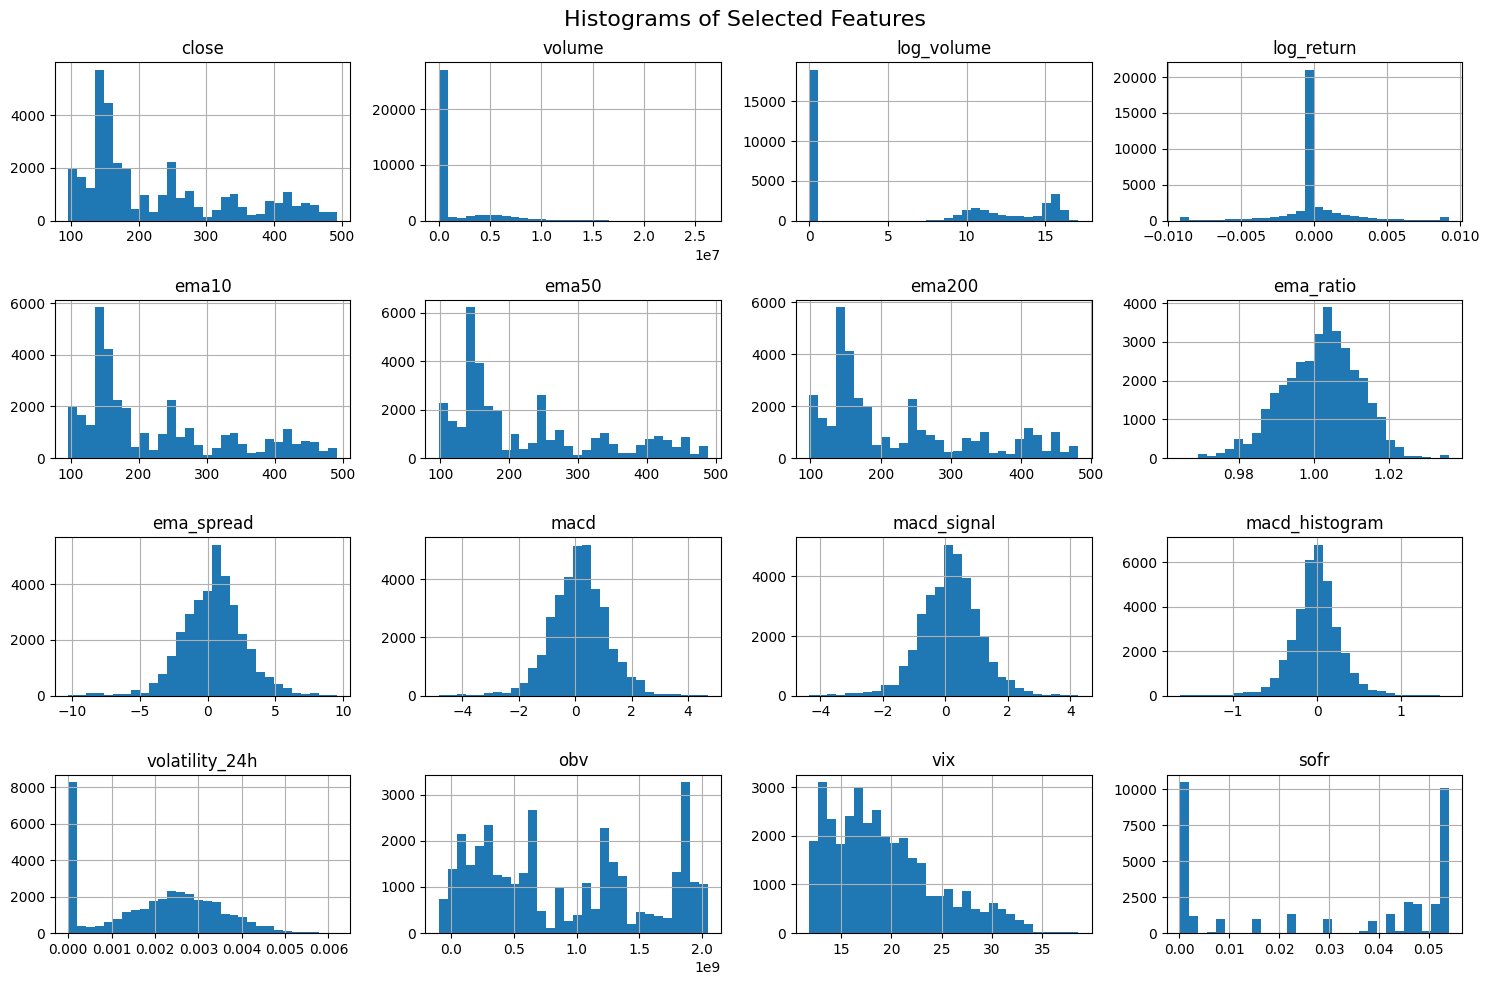

ema10 mean 225.80759768813593
ema50 mean 225.36877393422267
ema200 mean 223.57365619466268
----
ema10 std 106.93603084080694
ema50 std 106.66867717925673
ema200 std 105.3995484436774
----
macd mean: 0.14364494206149006
macd std: 0.9951104246071546
macd diff: 9.53192789355387
----
macd_signal mean: 0.15442484330517608
macd_signal std: 0.935790694857636
macd_signal diff: 8.603043185569089
----
macd_histogram mean: -0.010779901243686045
macd_histogram std: 0.28168286648074903
macd_histogram diff: 3.193263785528507
----
log_return.mean(): 4.458506289513307e-05
log_return.std(): 0.0024525701773443244
target_log_return.mean(): 4.461751712850037e-05
target_log_return.std(): 0.002452564752514506


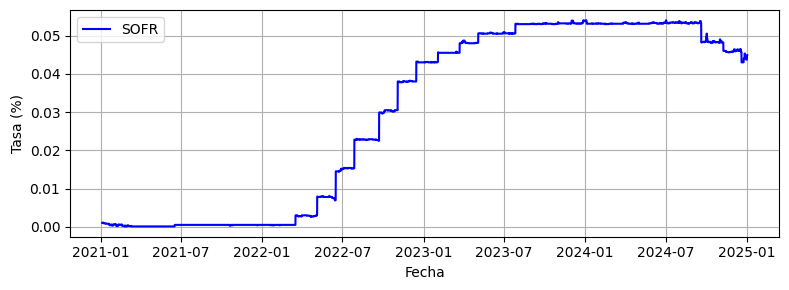

In [ ]:
# plot de los histogramas básicos
selected_cols = ['close','volume', 'log_volume', 'log_return', 'ema10', 'ema50', 'ema200', 'ema_ratio', 'ema_spread', 'macd', 'macd_signal', 'macd_histogram', 'volatility_24h', 'obv','vix','sofr']
df[selected_cols].hist(bins=30, figsize=(15, 10))
plt.suptitle('Histograms of Selected Features', fontsize=16)
plt.tight_layout()
plt.show()

# estadisticas de EMAs, MACD, y log_returns
print("ema10 mean", df["ema10"].mean())
print("ema50 mean", df["ema50"].mean())
print("ema200 mean", df["ema200"].mean())
print("----")
print("ema10 std", df["ema10"].std())
print("ema50 std", df["ema50"].std())
print("ema200 std", df["ema200"].std())

print("----")
print("macd mean:", df["macd"].mean())
print("macd std:", df["macd"].std())
print("macd diff:", df["macd"].max() - df["macd"].min())
print("----")

print("macd_signal mean:", df["macd_signal"].mean())
print("macd_signal std:", df["macd_signal"].std())
print("macd_signal diff:", df["macd_signal"].max() - df["macd_signal"].min())
print("----")
print("macd_histogram mean:", df["macd_histogram"].mean())
print("macd_histogram std:", df["macd_histogram"].std())
print("macd_histogram diff:", df["macd_histogram"].max() - df["macd_histogram"].min())
print("----")

print("log_return.mean():", df["log_return"].mean())
print("log_return.std():", df["log_return"].std())
print("target_log_return.mean():", df["target_log_return"].mean())
print("target_log_return.std():", df["target_log_return"].std())

# plot del SOFT
plt.figure(figsize=(8, 3))
plt.plot(df["datetime"], df['sofr'], label='SOFR', color='blue')
plt.xlabel('Fecha')
plt.ylabel('Tasa (%)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


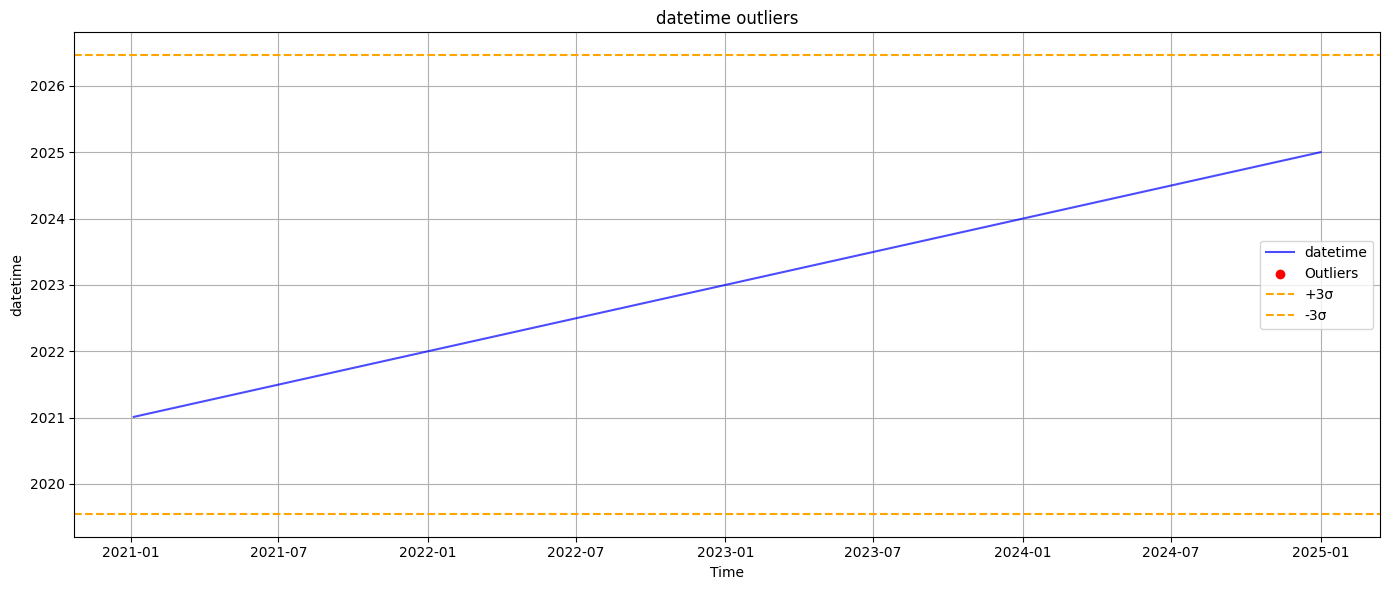

... 0/34980 outliers (0.00 %)


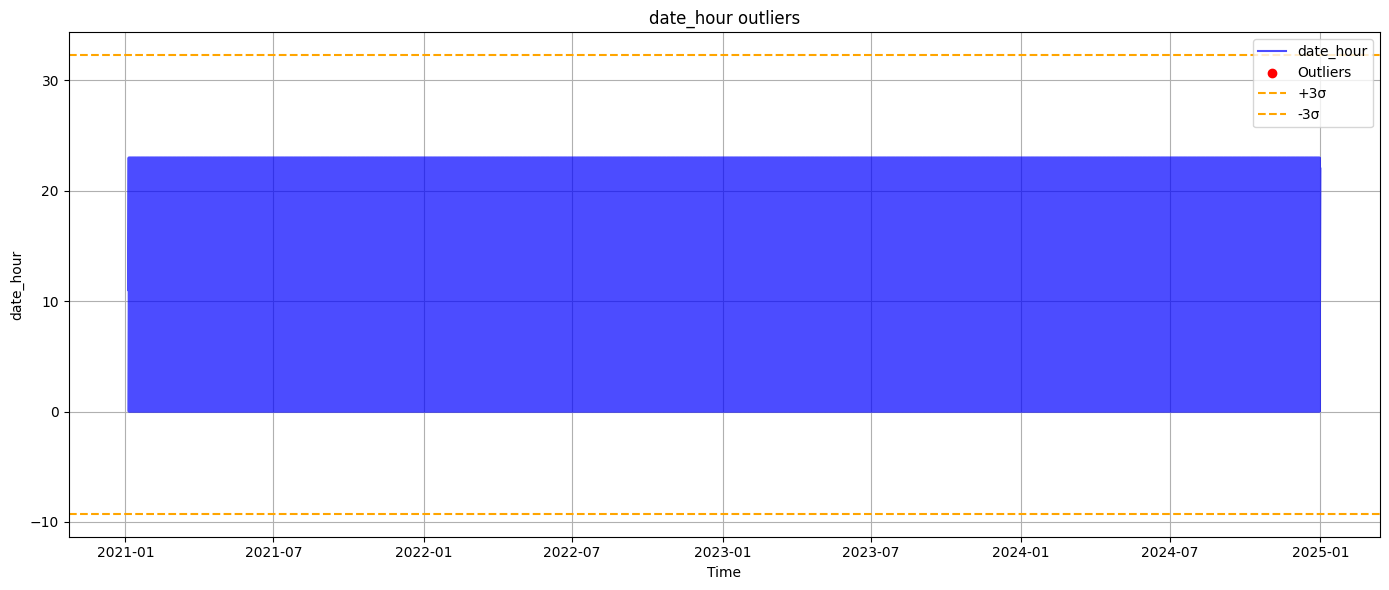

... 0/34980 outliers (0.00 %)


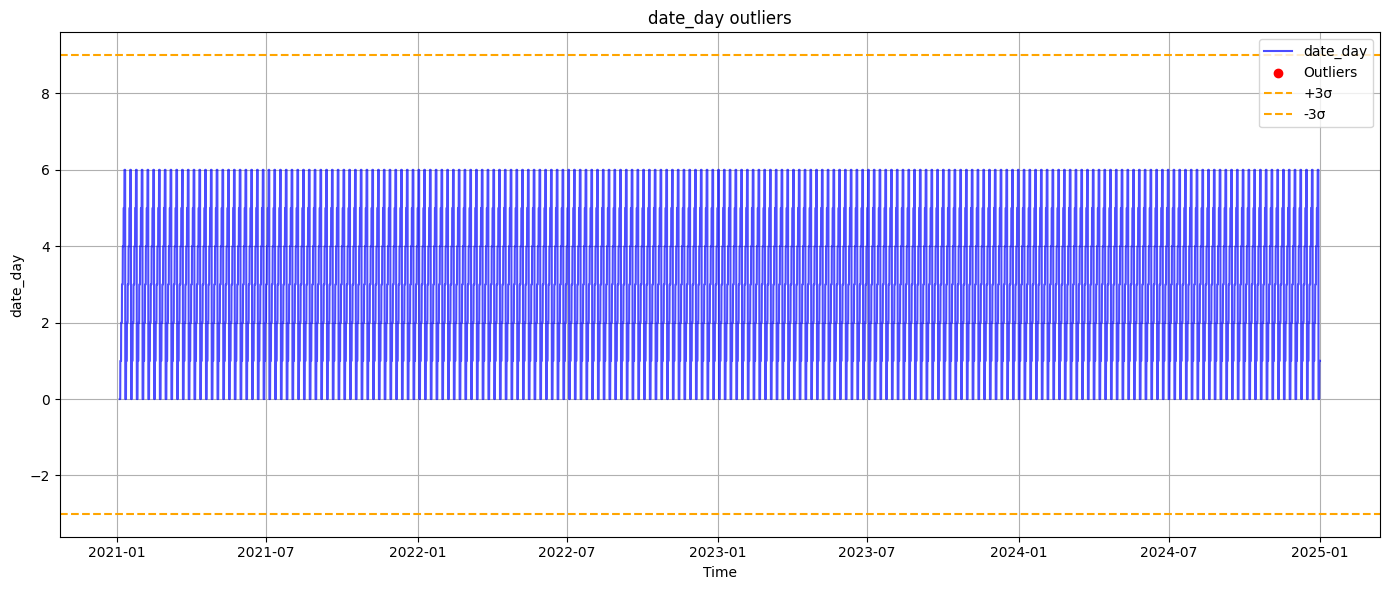

... 0/34980 outliers (0.00 %)


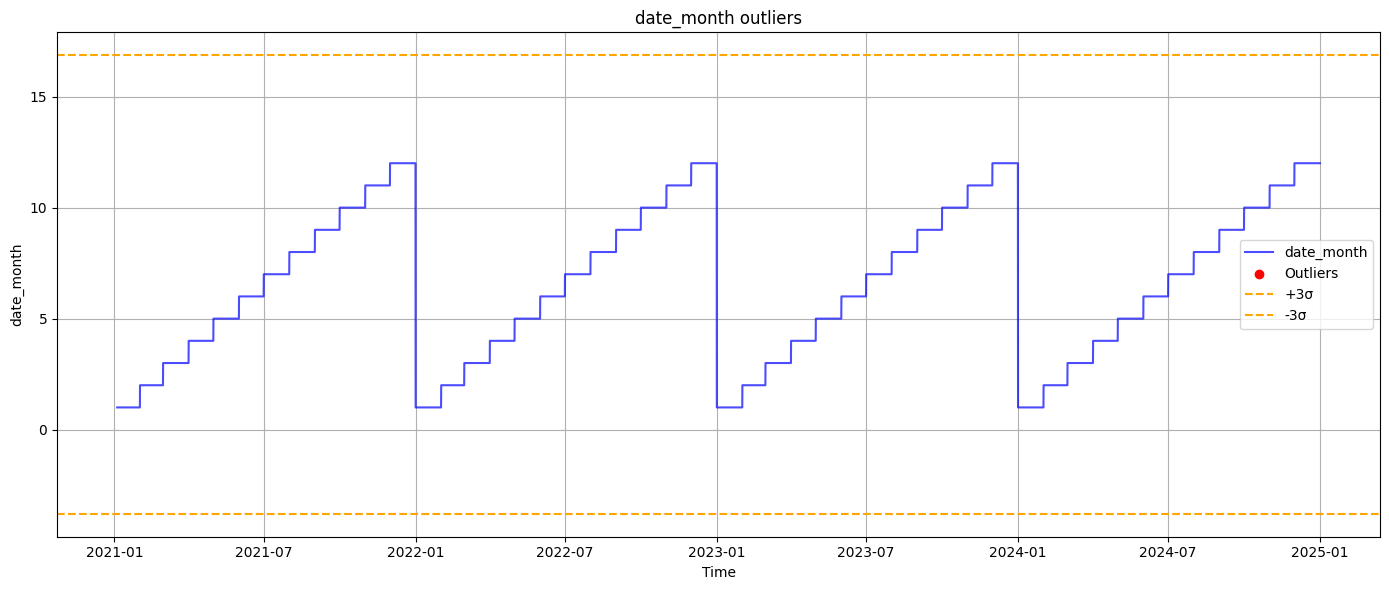

... 0/34980 outliers (0.00 %)


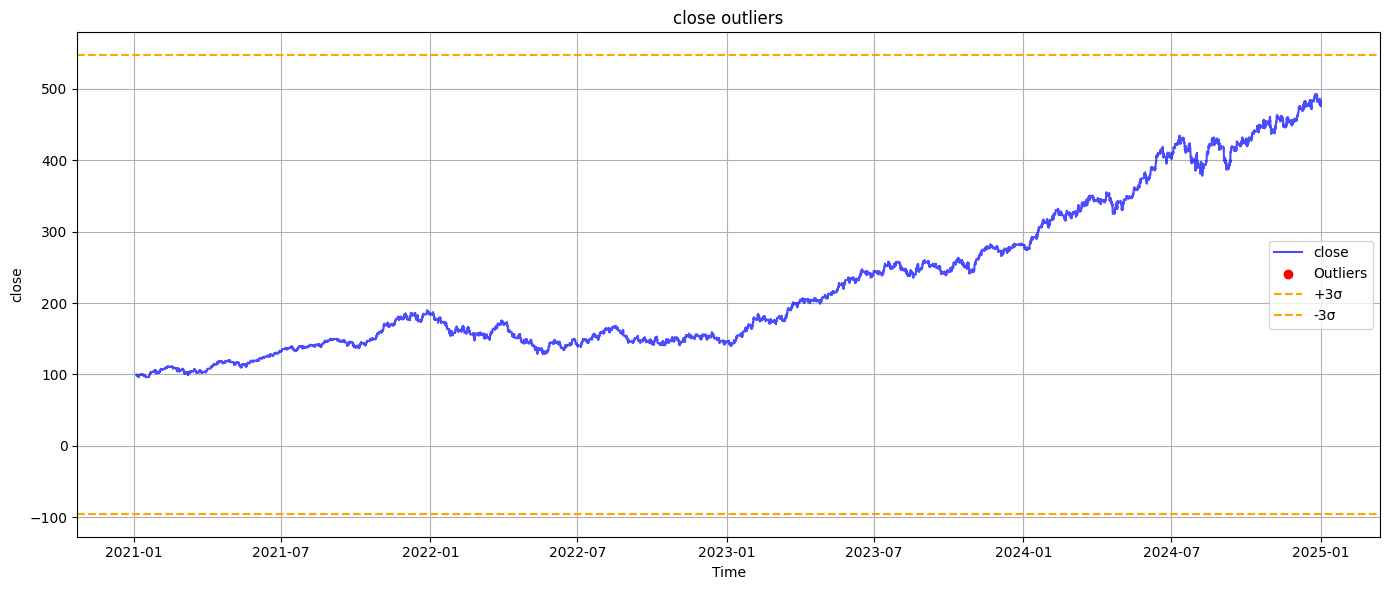

... 0/34980 outliers (0.00 %)


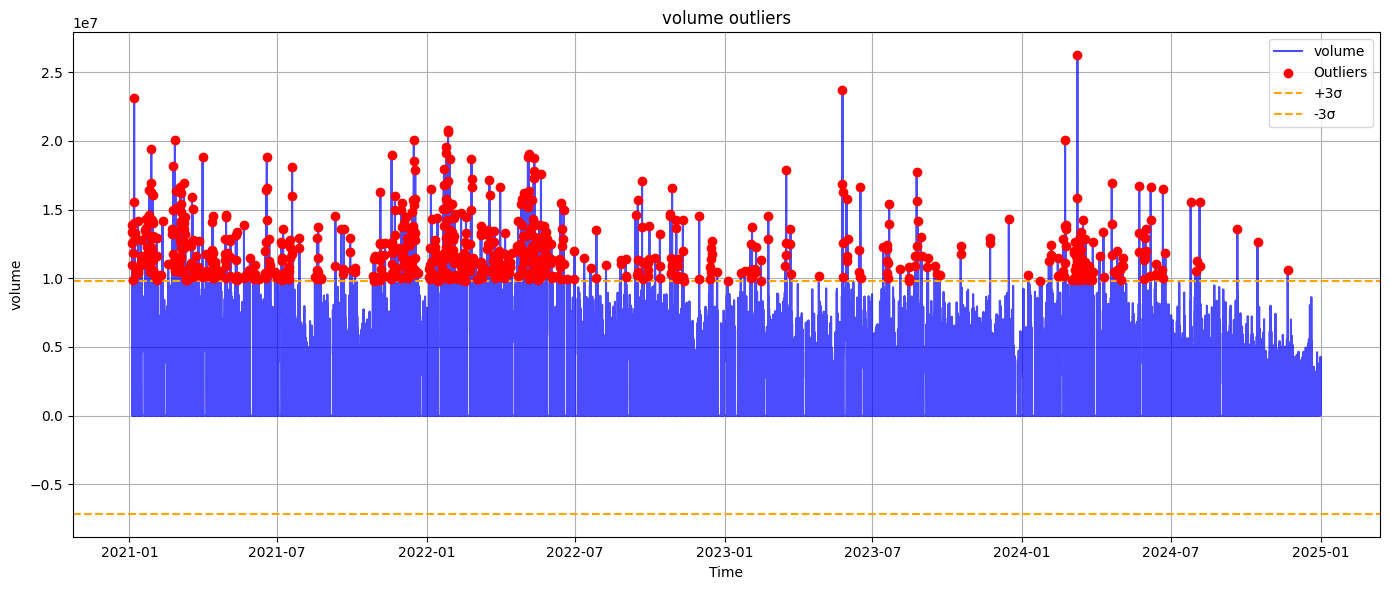

... 801/34980 outliers (2.29 %)


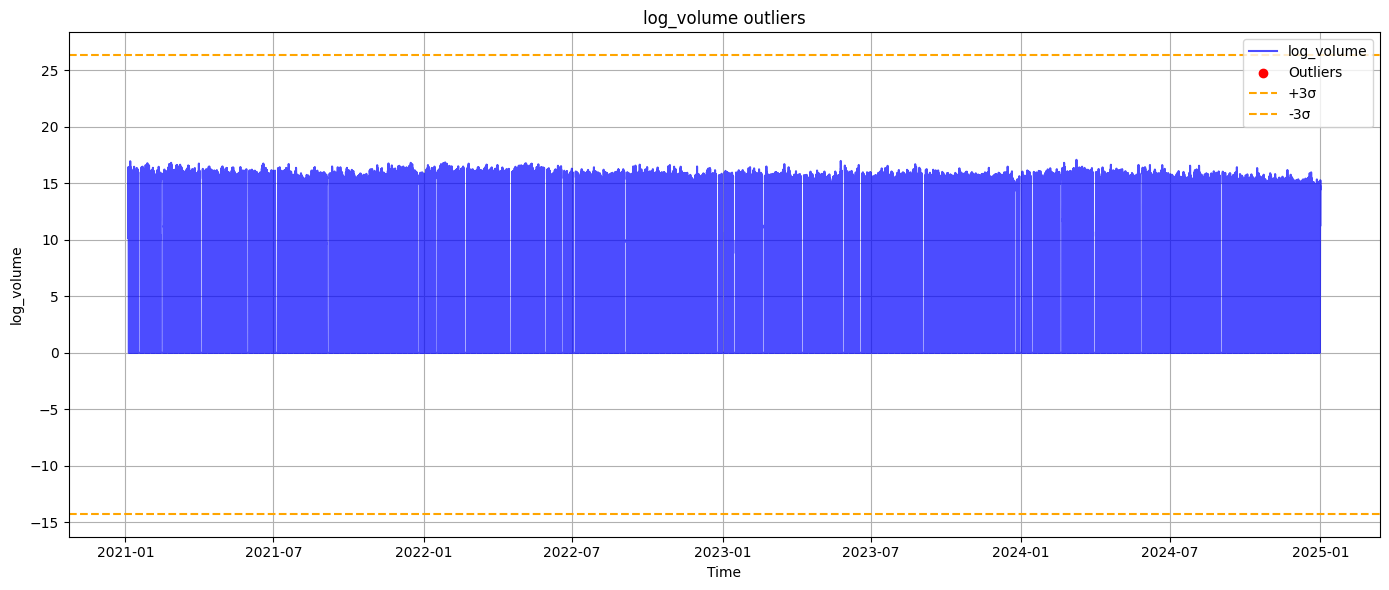

... 0/34980 outliers (0.00 %)


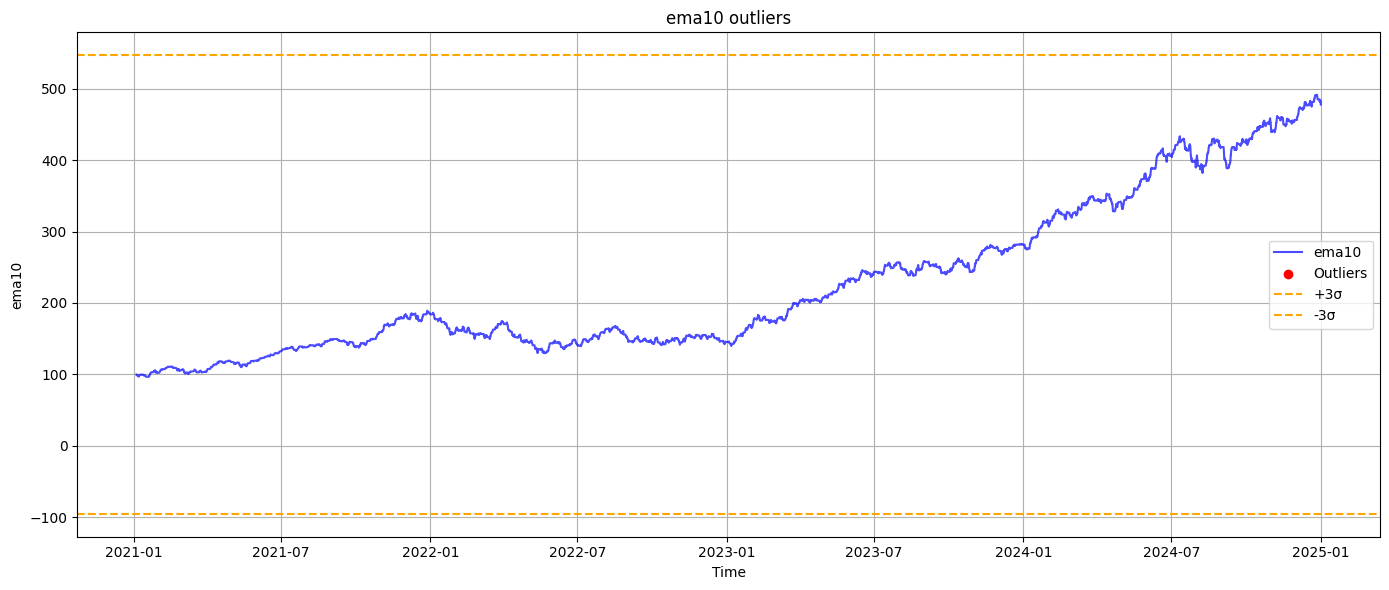

... 0/34980 outliers (0.00 %)


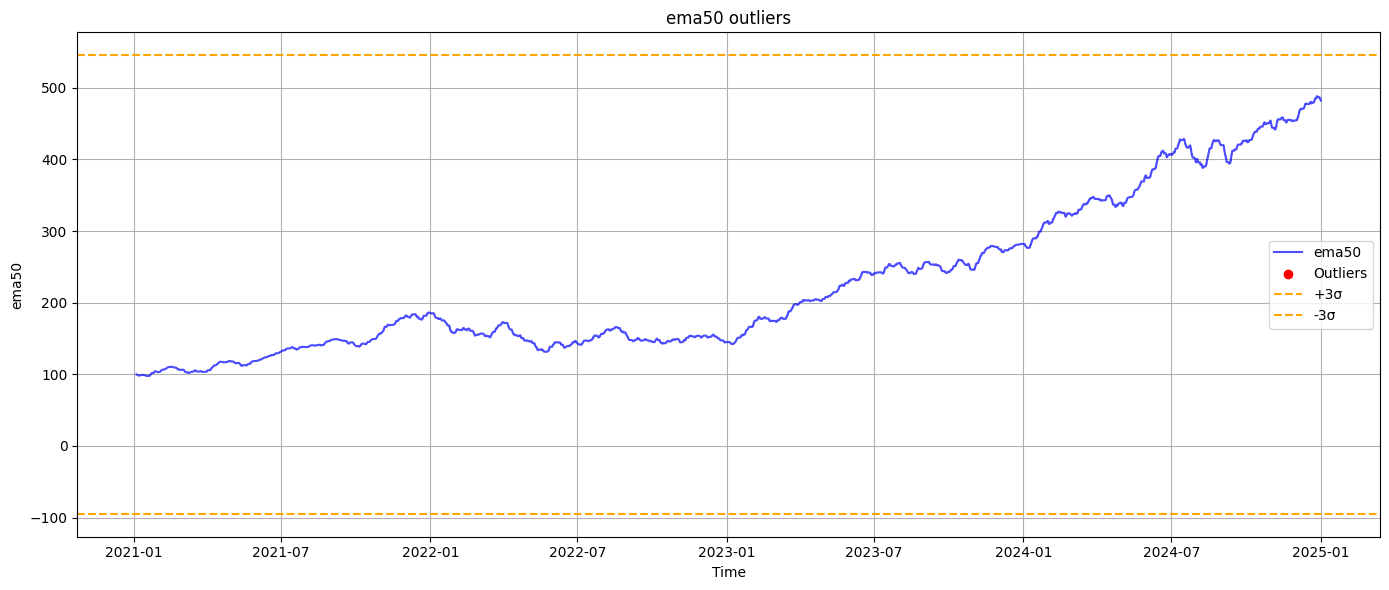

... 0/34980 outliers (0.00 %)


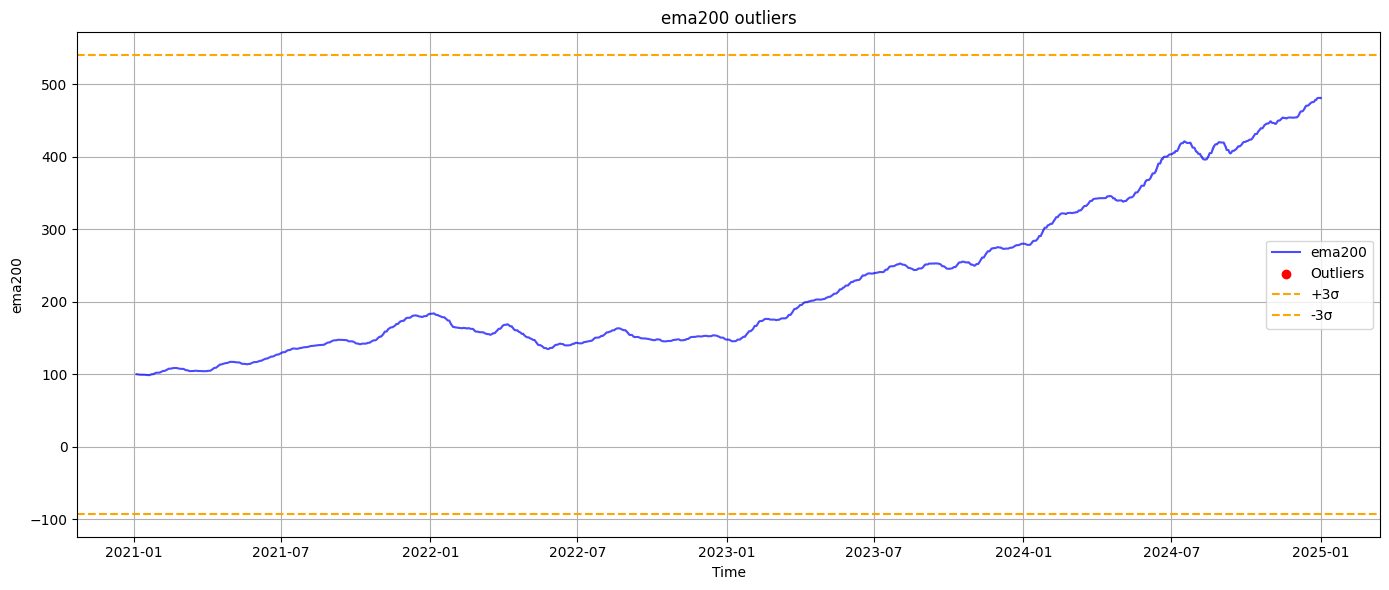

... 0/34980 outliers (0.00 %)


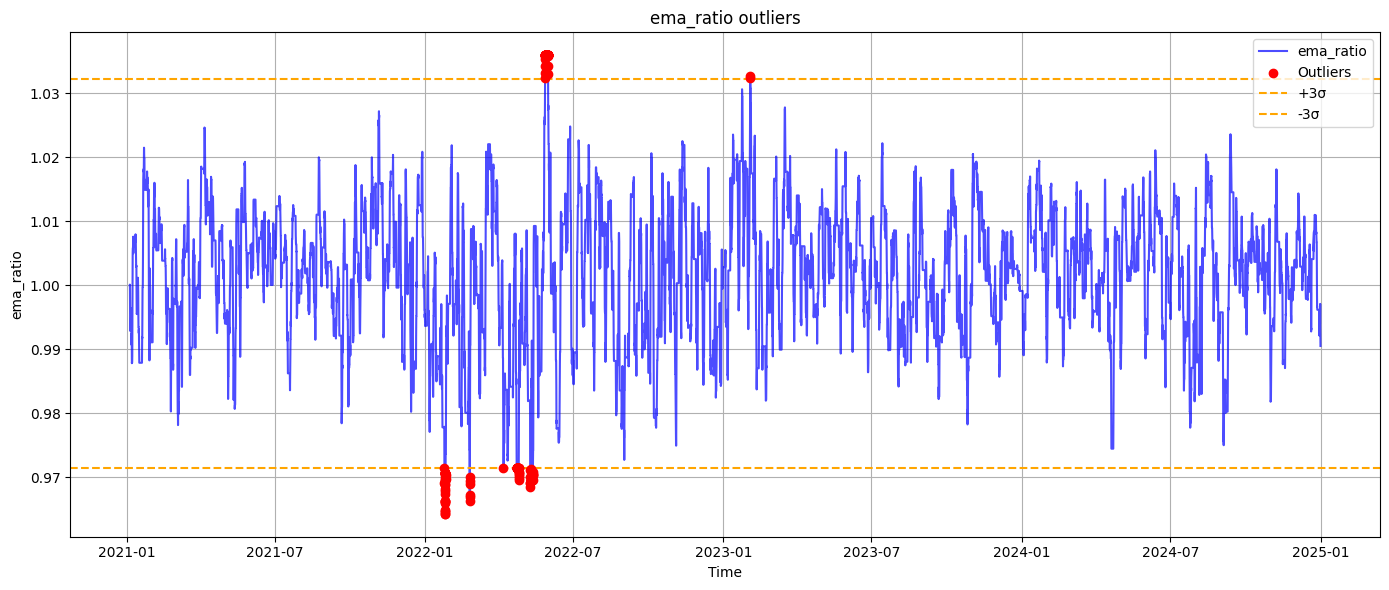

... 215/34980 outliers (0.61 %)


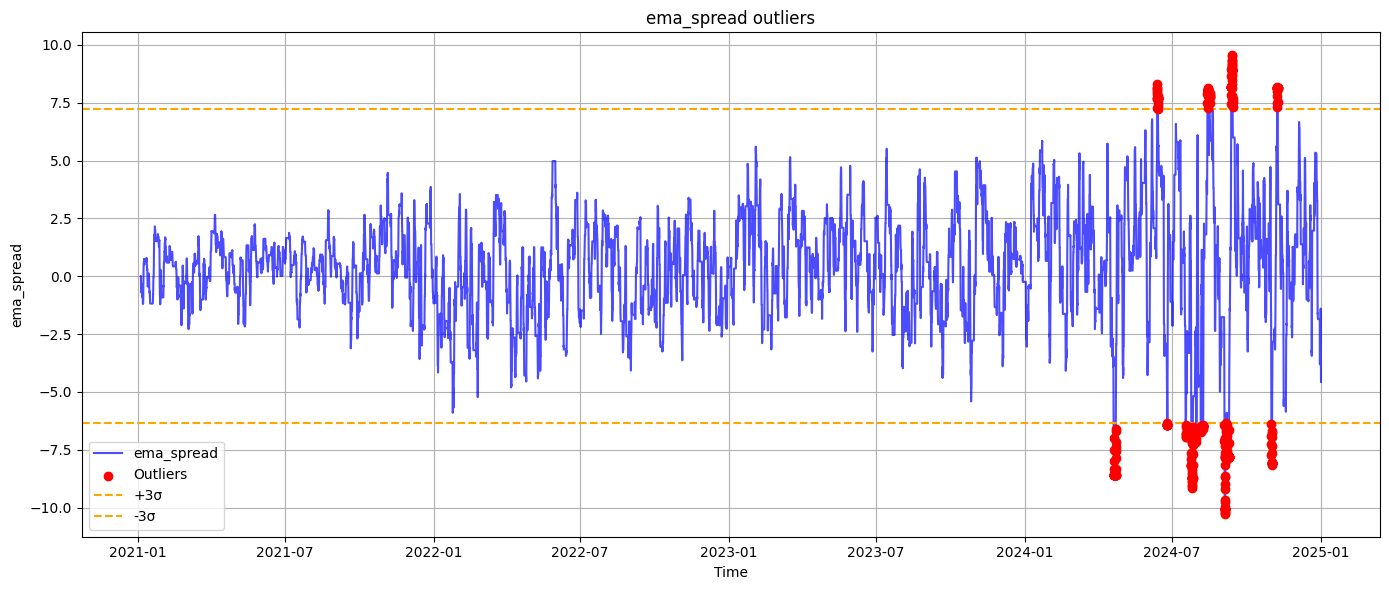

... 423/34980 outliers (1.21 %)


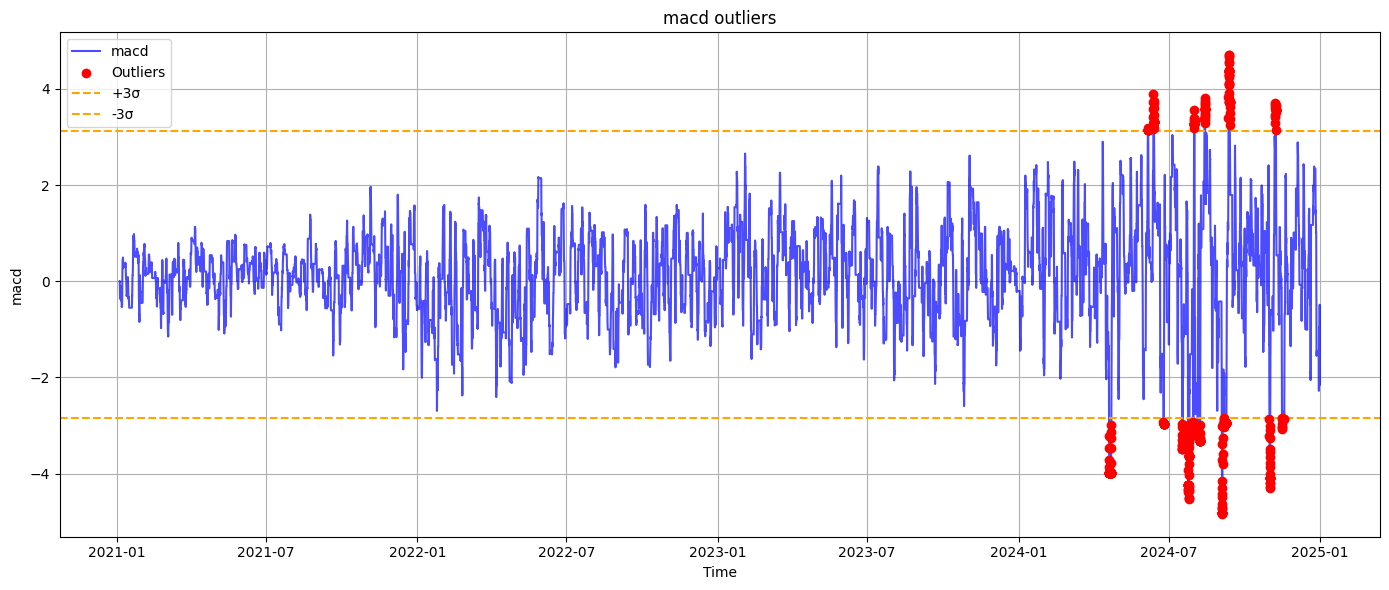

... 398/34980 outliers (1.14 %)


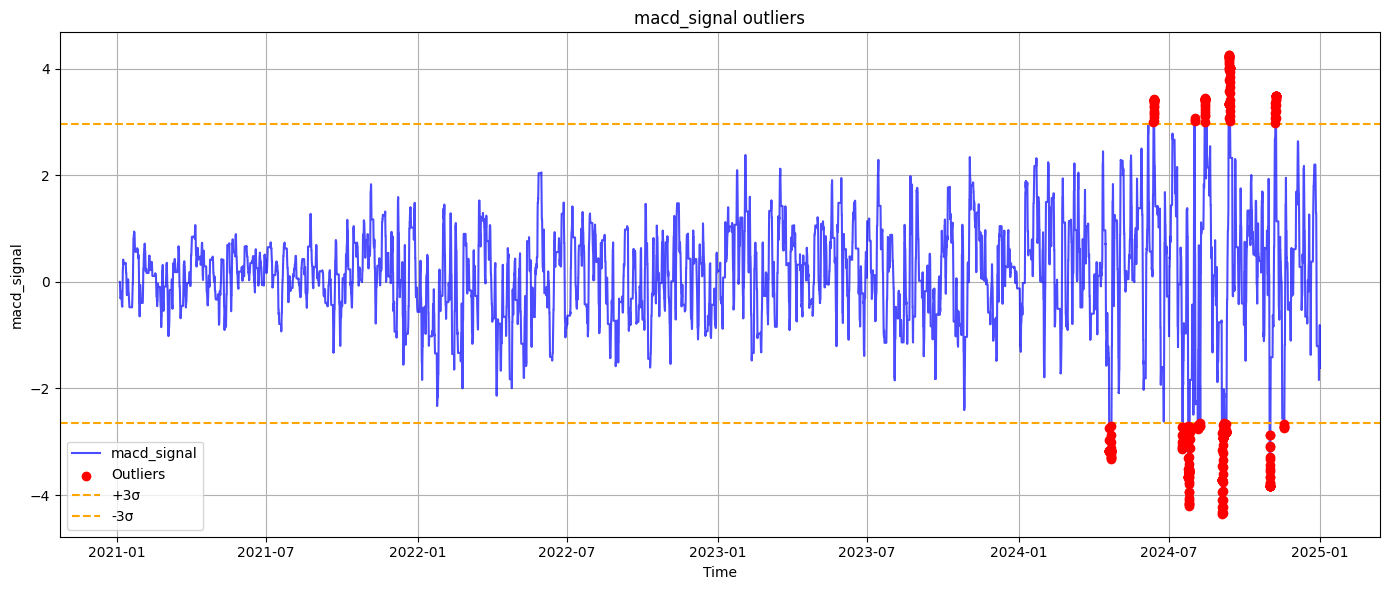

... 376/34980 outliers (1.07 %)


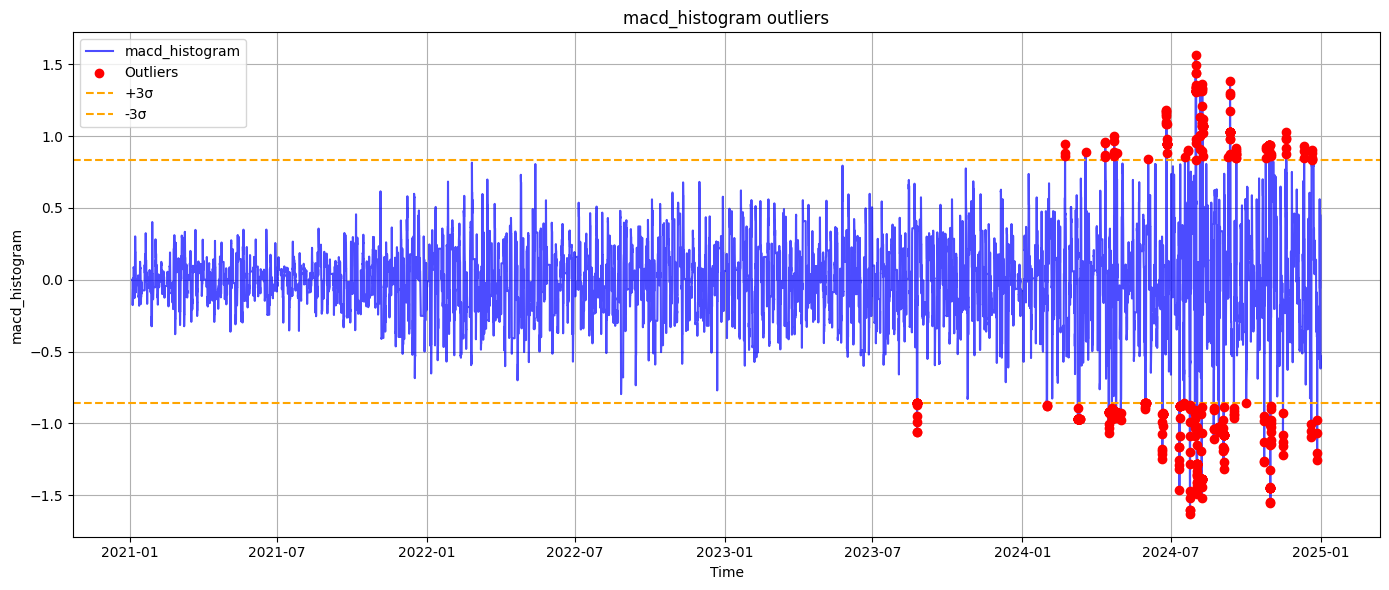

... 433/34980 outliers (1.24 %)


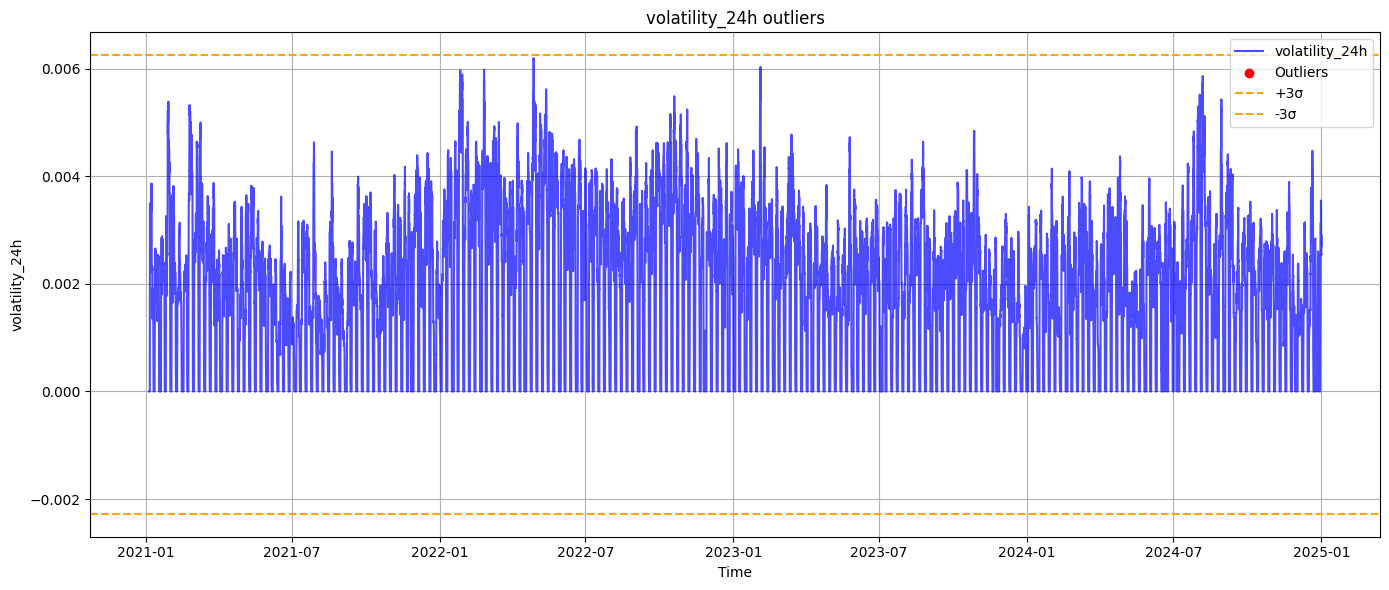

... 0/34980 outliers (0.00 %)


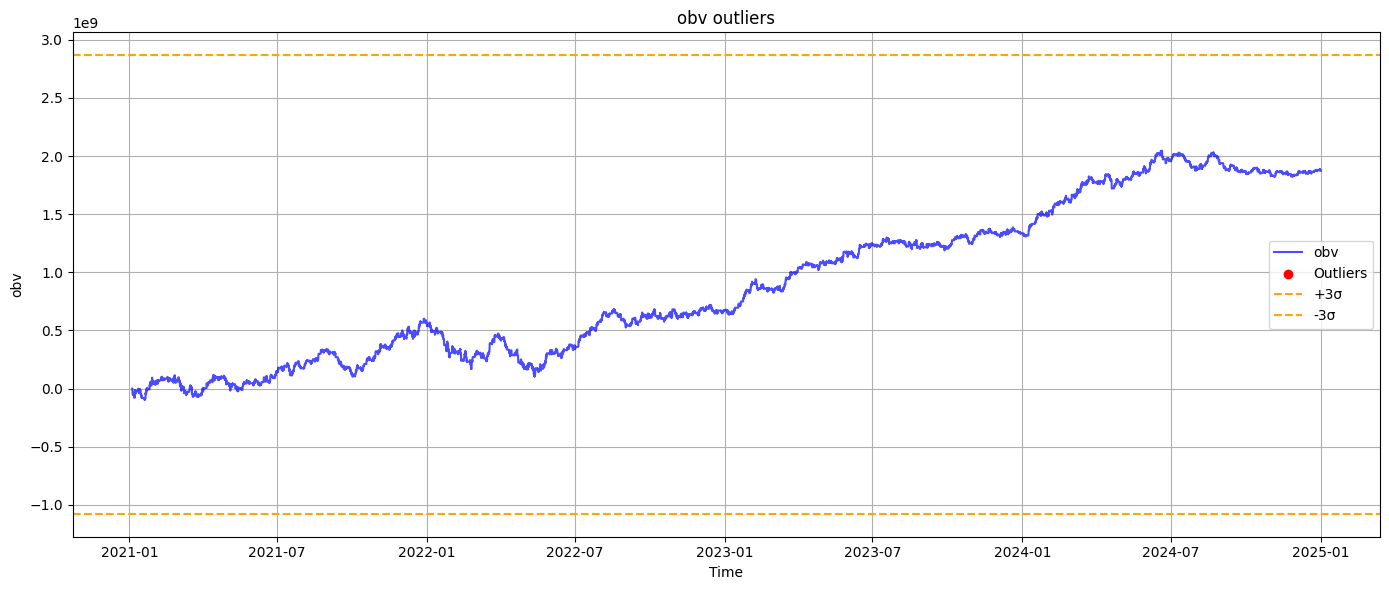

... 0/34980 outliers (0.00 %)


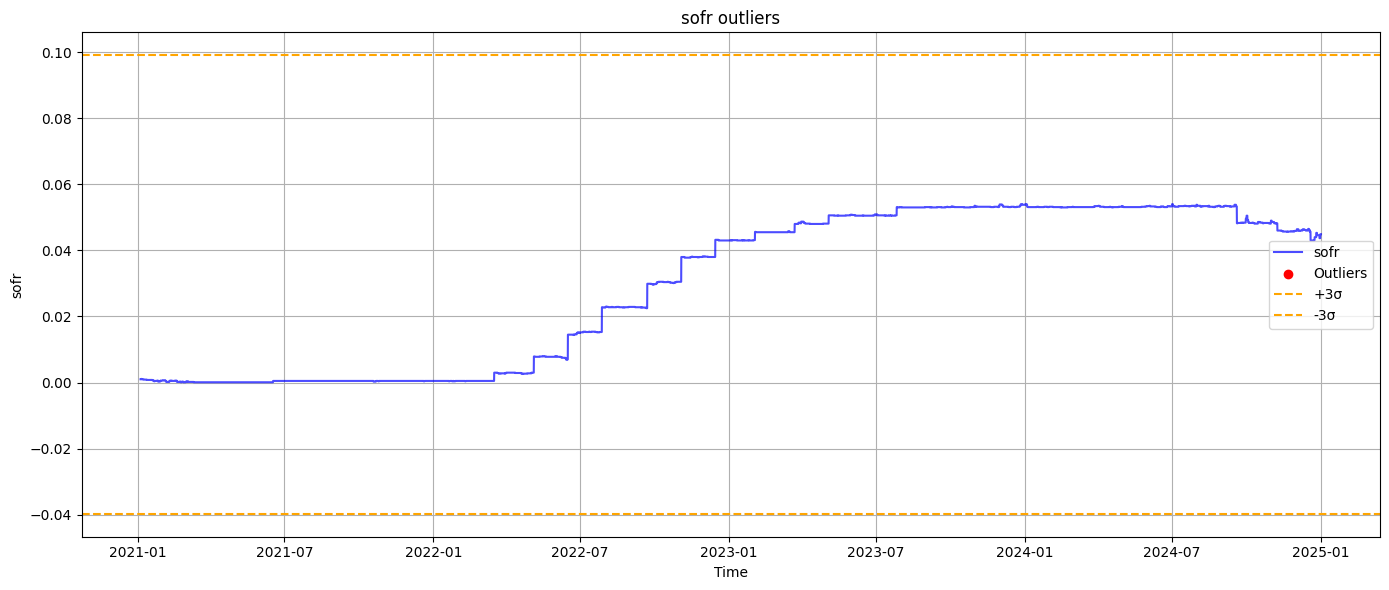

... 0/34980 outliers (0.00 %)


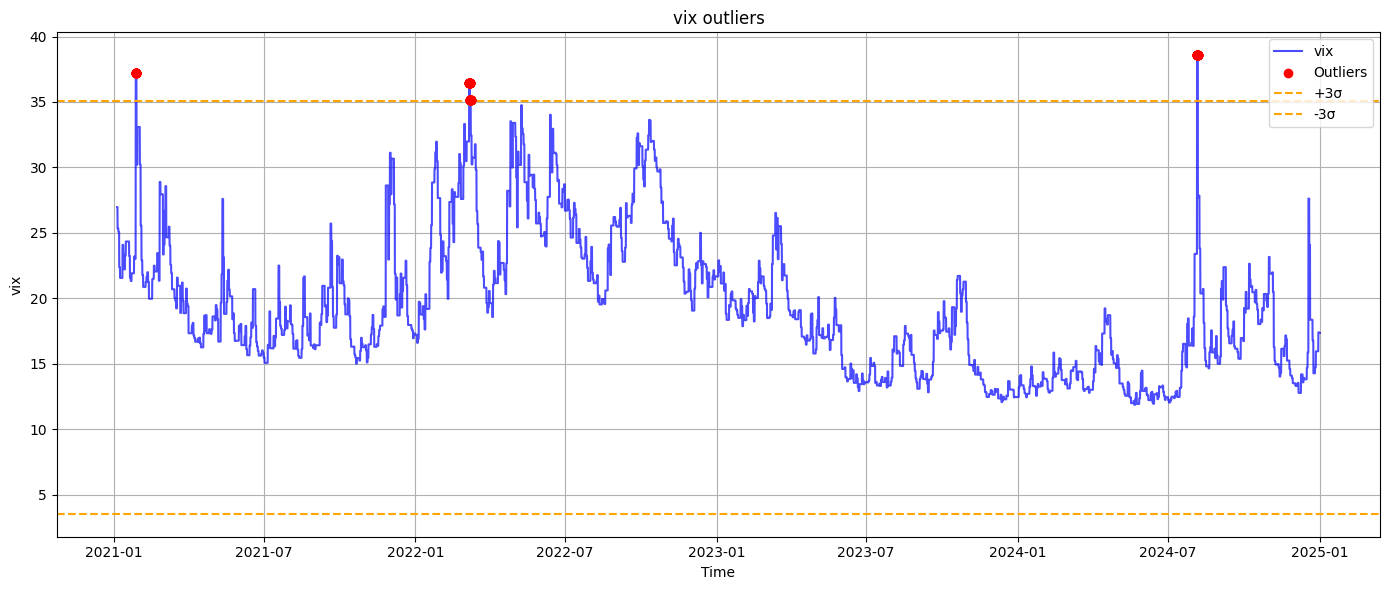

... 96/34980 outliers (0.27 %)


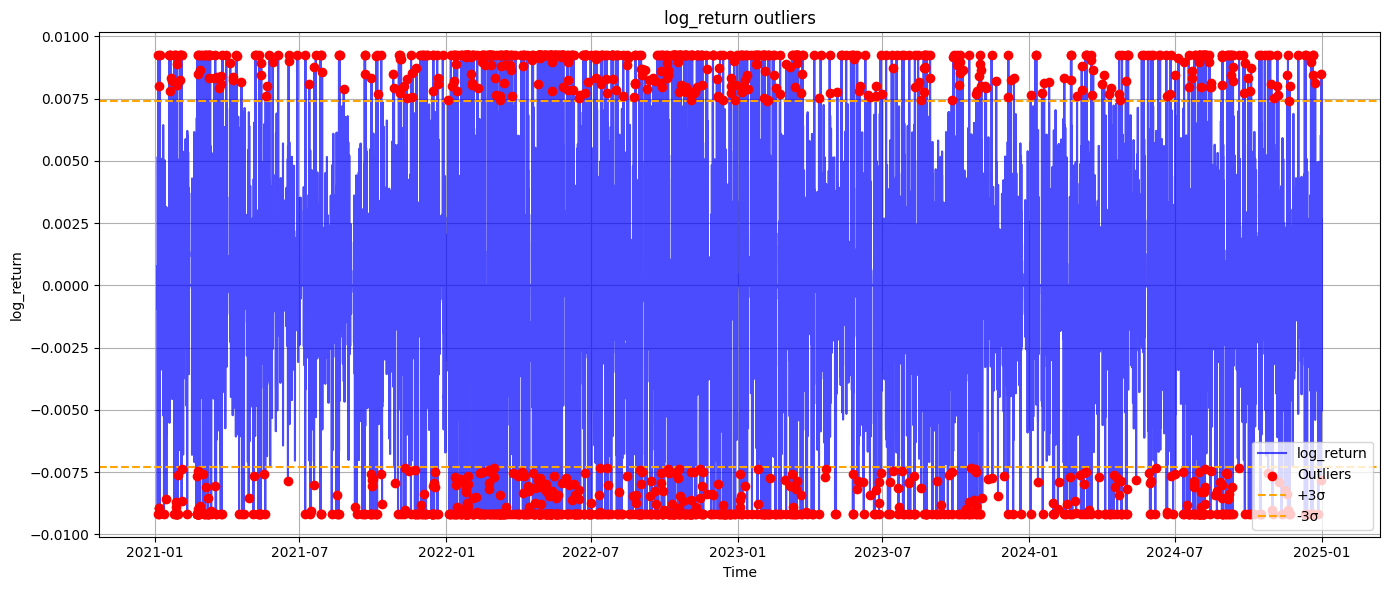

... 1389/34980 outliers (3.97 %)


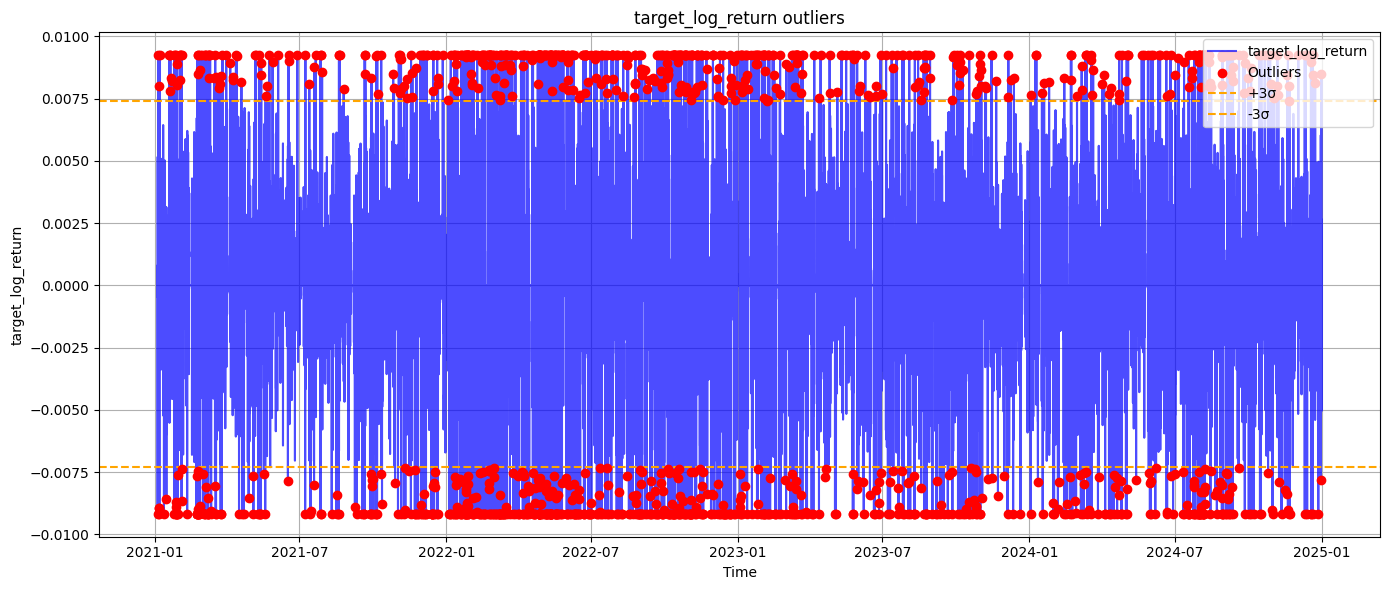

... 1389/34980 outliers (3.97 %)


,datetime,date_hour,date_day,date_month,close,volume,log_volume,ema10,ema50,ema200,ema_ratio,ema_spread,macd,macd_signal,macd_histogram,volatility_24h,obv,sofr,vix,log_return,target_log_return
0,2021-01-04 11:00:00,11,0,1,99.906747,26015,10.166467,99.906747,99.906747,99.906747,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.0010,26.97,-0.000933,0.000783
1,2021-01-04 12:00:00,12,0,1,99.985049,199527,12.203710,99.920984,99.909818,99.907526,1.000112,0.011166,0.006246,0.001249,0.004997,0.000000,1.995270e+05,0.0010,26.97,0.000783,-0.001044
2,2021-01-04 13:00:00,13,0,1,99.880734,255584,12.451310,99.913666,99.908677,99.907259,1.000050,0.004989,0.002748,0.001549,0.001199,0.000000,-5.605700e+04,0.0010,26.97,-0.001044,-0.002612
3,2021-01-04 14:00:00,14,0,1,99.620235,10999519,16.213362,99.860315,99.897366,99.904403,0.999629,-0.037051,-0.020805,-0.002922,-0.017884,0.000000,-1.105558e+07,0.0010,26.97,-0.002612,-0.001989
4,2021-01-04 15:00:00,15,0,1,99.422310,13845932,16.443502,99.780677,99.878736,99.899607,0.999018,-0.098059,-0.054811,-0.013300,-0.041511,0.000000,-2.490151e+07,0.0010,26.97,-0.001989,-0.009177
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34975,2024-12-31 18:00:00,18,1,12,475.395843,1898940,14.456807,479.881709,483.276316,481.005555,0.992976,-3.394607,-1.561455,-1.040047,-0.521409,0.002829,1.874310e+09,0.0449,17.35,-0.005047,0.002644
34976,2024-12-31 19:00:00,19,1,12,476.654662,1824399,14.416762,479.294973,483.016643,480.962262,0.992295,-3.721670,-1.731628,-1.178363,-0.553265,0.002913,1.876135e+09,0.0449,17.35,0.002644,-0.002787
34977,2024-12-31 20:00:00,20,1,12,475.328246,4283773,15.270345,478.573750,482.715138,480.906202,0.991421,-4.141388,-1.951031,-1.332897,-0.618134,0.002539,1.871851e+09,0.0449,17.35,-0.002787,0.000548
34978,2024-12-31 21:00:00,21,1,12,475.588699,218644,12.295205,478.031013,482.435669,480.853292,0.990870,-4.404656,-2.079917,-1.482301,-0.597616,0.002544,1.872069e+09,0.0449,17.35,0.000548,0.000202


In [ ]:
# plot de outliers de las features
def plot_outliers_temporales(df, col='log_return', threshold_std=3):
    """
    Muestra un gráfico de una serie temporal con los outliers destacados,
    definidos como valores por fuera de ±threshold_std desviaciones estándar.
    """
    # Asegurar que el índice sea datetime
    if not pd.api.types.is_datetime64_any_dtype(df.index):
        df = df.copy()
        df.index = pd.to_datetime(df.index)

    # Calcular media y desviación estándar
    mu = df[col].mean()
    sigma = df[col].std()

    # Límites
    upper = mu + threshold_std * sigma
    lower = mu - threshold_std * sigma

    # Detectar outliers
    outliers = df[(df[col] > upper) | (df[col] < lower)]

    # Graficar
    plt.figure(figsize=(14, 6))
    plt.plot(df["datetime"], df[col], color='blue', alpha=0.7, label=col) 
    plt.scatter(outliers["datetime"], outliers[col], color='red', label='Outliers', zorder=5)
    plt.axhline(upper, color='orange', linestyle='--', label=f'+{threshold_std}σ')
    plt.axhline(lower, color='orange', linestyle='--', label=f'-{threshold_std}σ')

    plt.xlabel("Time")    
    plt.title(col + " outliers")
    plt.ylabel(col)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    
    print(f"... {len(outliers)}/{len(df)} outliers ({(len(outliers)/len(df))*100:.2f} %)")
 
for column in df.columns:
    plot_outliers_temporales(df, column)

display(df)

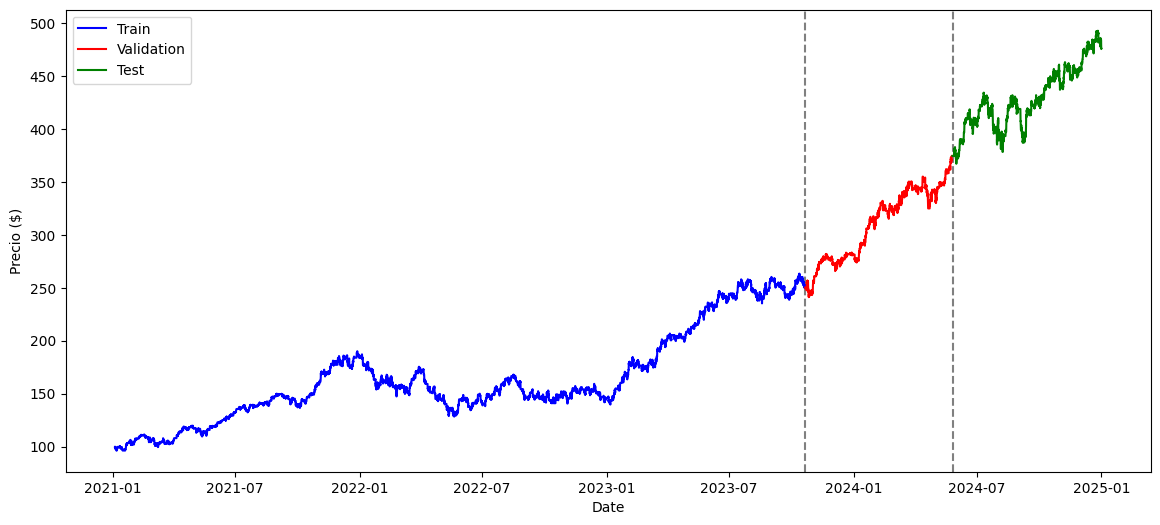

In [ ]:
# series temporales

# calcula las fechas de los datasets de TRAIN, VAL y TEST
df_dates = df.set_index("datetime")
dates = calulate_train_validation_test_dates(df_dates)
df_train, df_validation, df_test = split_df(df_dates, dates)
 
df_train_plot = df_train.copy()
df_train_plot = df_train_plot.reset_index()

df_validation_plot = df_validation.copy()
df_validation_plot = df_validation_plot.reset_index()

df_test_plot = df_test.copy()
df_test_plot = df_test_plot.reset_index()

 # plot prices acumulated
plt.figure(figsize=(14,6))
plt.axvline(df_validation_plot.iloc[0][DATETIME_COL], color='gray', linestyle='--')
plt.axvline(df_test_plot.iloc[0][DATETIME_COL], color='gray', linestyle='--')

plt.plot(df_train_plot[DATETIME_COL], df_train_plot["close"], label="Train", color="blue")

plt.plot(df_validation_plot[DATETIME_COL], df_validation_plot["close"], label="Validation", color="red")

plt.plot(df_test_plot[DATETIME_COL], df_test_plot["close"], label="Test", color="green")

plt.xlabel("Date")
plt.ylabel("Precio ($)")
plt.legend()
plt.show()

,date_hour,date_day,date_month,close,volume,log_volume,ema10,ema50,ema200,ema_ratio,ema_spread,macd,macd_signal,macd_histogram,volatility_24h,obv,sofr,vix,log_return,target_log_return
count,24469.000000,24469.000000,24469.000000,24469.000000,2.446900e+04,24469.000000,24469.000000,24469.000000,24469.000000,24469.000000,24469.000000,24469.000000,24469.000000,24469.000000,24469.000000,2.446900e+04,24469.000000,24469.000000,24469.000000,24469.000000
mean,11.502922,2.996444,6.209203,164.258978,1.439257e+06,6.047897,164.215893,163.942789,162.906024,1.001655,0.273104,0.092319,0.098260,-0.005941,0.002090,5.352878e+08,0.020195,21.053969,0.000037,0.000037
std,6.922187,1.998249,3.306617,42.199523,3.000376e+06,6.768789,42.189478,42.066929,41.486843,0.010772,1.757686,0.783416,0.732078,0.219280,0.001472,4.061353e+08,0.021500,5.029869,0.002567,0.002567
min,0.000000,0.000000,1.000000,96.139396,0.000000e+00,0.000000,96.730305,97.649090,98.568561,0.964325,-5.908702,-2.695514,-2.330201,-1.062281,0.000000,-9.868536e+07,0.000100,12.820000,-0.009177,-0.009177
25%,6.000000,1.000000,3.000000,140.369617,0.000000e+00,0.000000,140.464694,140.424034,140.163045,0.993853,-0.957773,-0.444586,-0.411202,-0.137630,0.000494,2.050739e+08,0.000500,17.200000,0.000000,0.000000
50%,12.000000,3.000000,6.000000,152.677431,0.000000e+00,0.000000,152.645114,152.972597,152.142141,1.002561,0.402070,0.133182,0.130412,-0.000635,0.002329,4.598732e+08,0.007800,20.020000,0.000000,0.000000
75%,18.000000,5.000000,9.000000,179.891707,3.359160e+05,12.724619,179.614958,179.493876,178.766459,1.009356,1.466577,0.614056,0.610562,0.126038,0.003233,8.479470e+08,0.045500,24.230000,0.000000,0.000000
max,23.000000,6.000000,12.000000,263.337279,2.369536e+07,16.980790,262.453831,260.160236,255.168425,1.035934,5.598746,2.654133,2.378278,0.815468,0.006197,1.322546e+09,0.053300,37.210000,0.009243,0.009243


,date_hour,date_day,date_month,close,volume,log_volume,ema10,ema50,ema200,ema_ratio,ema_spread,macd,macd_signal,macd_histogram,volatility_24h,obv,sofr,vix,log_return,target_log_return
count,5232.000000,5232.000000,5232.000000,5232.000000,5.232000e+03,5232.000000,5232.000000,5232.000000,5232.000000,5232.000000,5232.000000,5232.000000,5232.000000,5232.000000,5232.000000,5.232000e+03,5232.000000,5232.000000,5232.000000,5232.000000
mean,11.500000,3.009174,5.683486,309.615030,1.258484e+06,6.035928,309.546494,308.656209,305.424286,1.002878,0.890285,0.306400,0.338882,-0.032482,0.001661,1.553619e+09,0.053183,14.168165,0.000077,0.000077
std,6.922848,2.000170,4.110774,33.505601,2.623821e+06,6.784996,33.513114,33.322852,32.872997,0.008100,2.469602,1.106190,1.014137,0.320877,0.001174,2.025428e+08,0.000187,2.035582,0.002033,0.002033
min,0.000000,0.000000,1.000000,241.123481,0.000000e+00,0.000000,243.464071,245.812240,249.441720,0.974494,-8.593953,-3.977727,-3.326701,-1.063970,0.000000,1.244579e+09,0.053000,11.860000,-0.009177,-0.009177
25%,5.750000,1.000000,2.000000,277.063398,0.000000e+00,0.000000,277.131291,277.598743,274.663177,0.998135,-0.523510,-0.282641,-0.245077,-0.209724,0.000336,1.343430e+09,0.053100,12.920000,0.000000,0.000000
50%,11.500000,3.000000,4.000000,318.741057,0.000000e+00,0.000000,318.468936,317.619975,310.706375,1.002930,0.873595,0.268512,0.281291,-0.009575,0.001822,1.528080e+09,0.053100,13.490000,0.000000,0.000000
75%,17.250000,5.000000,11.000000,340.821595,4.204242e+05,12.949021,341.004320,339.109190,339.310265,1.008095,2.445604,1.033664,1.045269,0.138063,0.002582,1.772510e+09,0.053200,14.740000,0.000000,0.000000
max,23.000000,6.000000,12.000000,374.464048,2.622953e+07,17.082396,373.265148,369.234487,359.812278,1.020501,5.854967,2.900280,2.447984,0.999160,0.004846,1.869471e+09,0.054000,21.710000,0.009243,0.009243


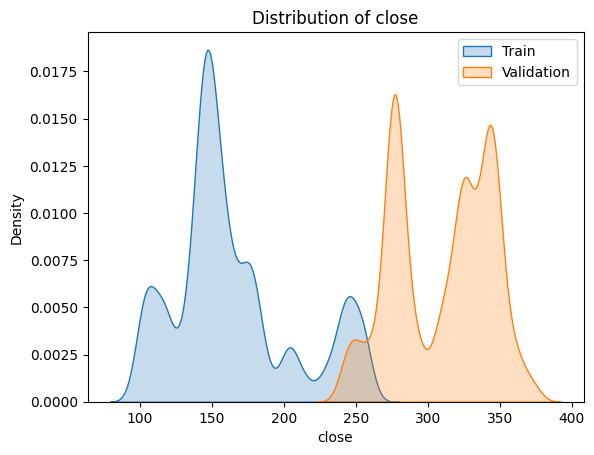

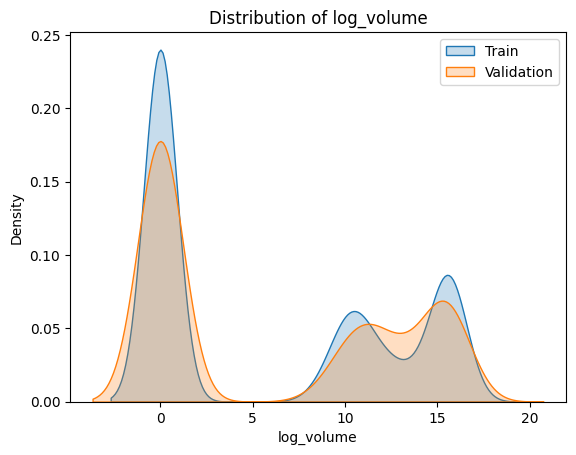

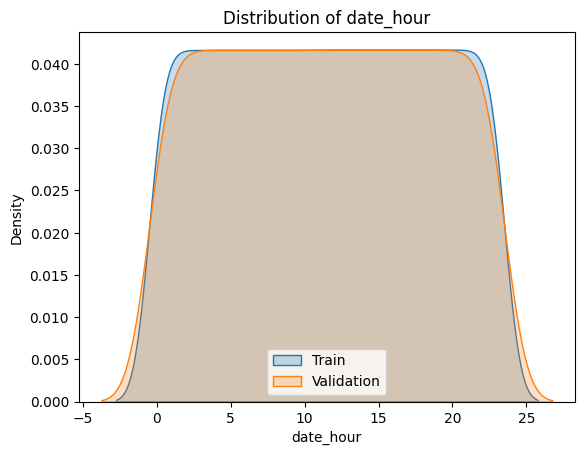

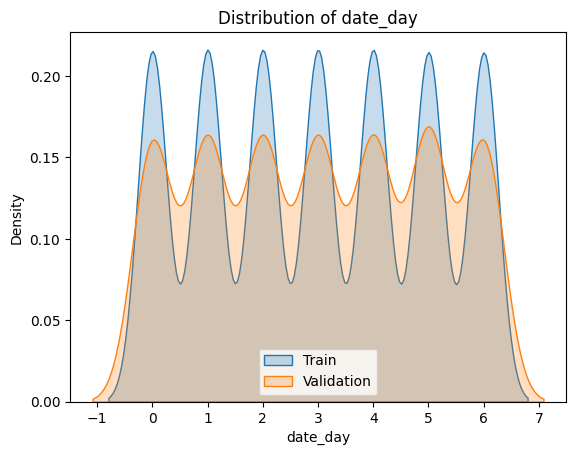

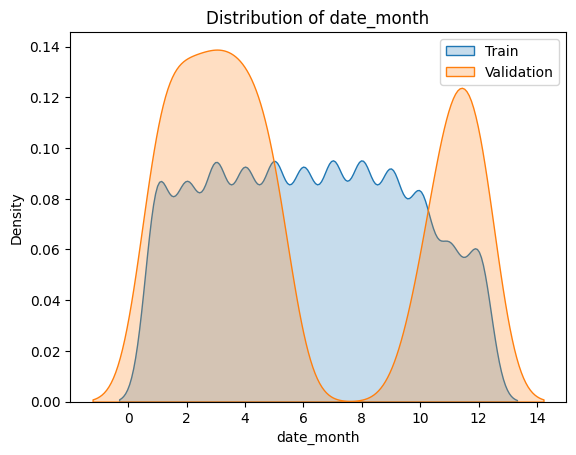

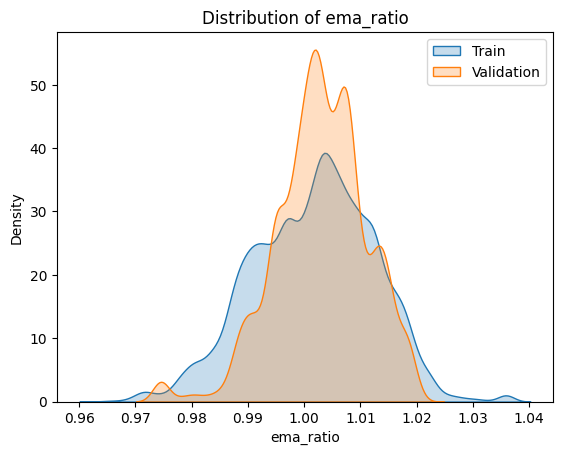

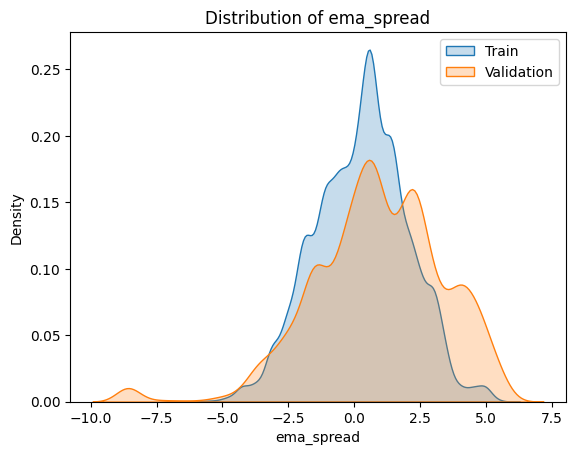

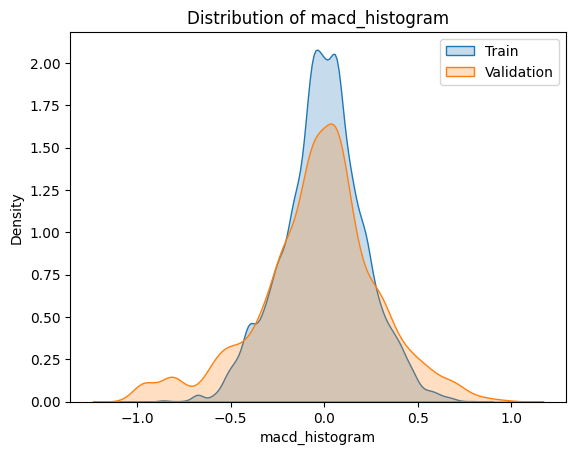

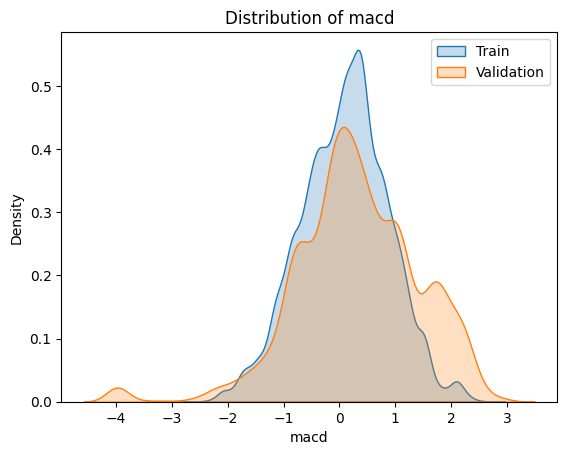

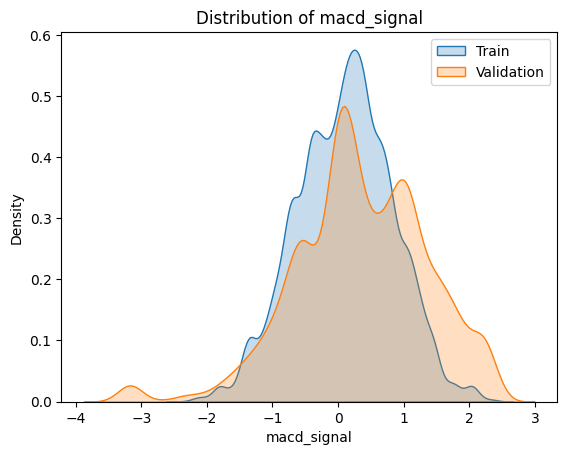

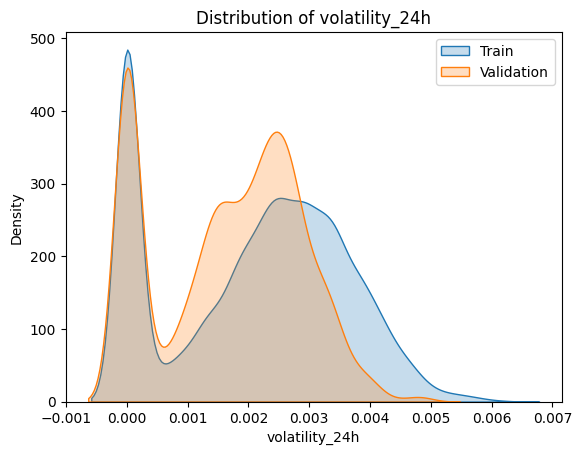

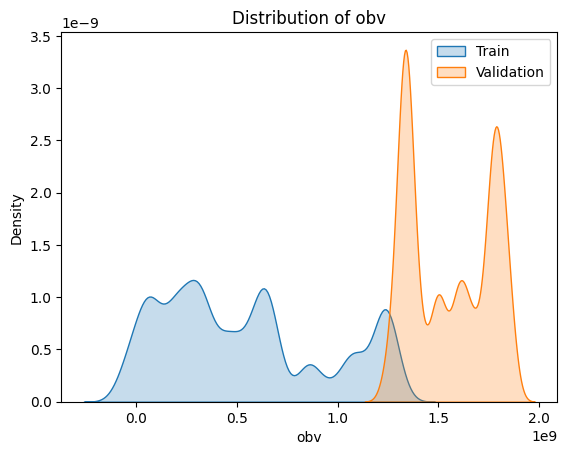

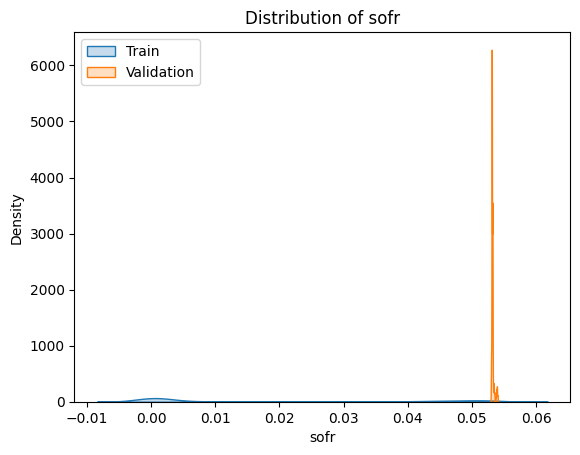

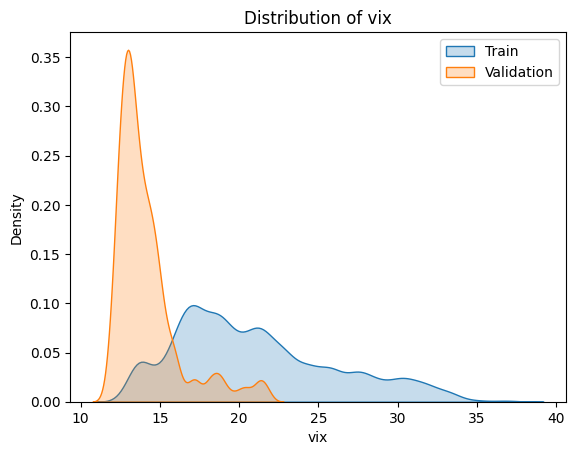

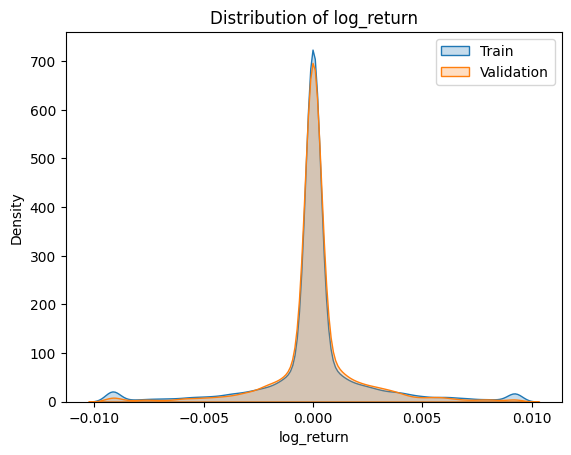

In [13]:
# check estability between ttrain and validation and test
display(df_train.describe())
display(df_validation.describe())

import matplotlib.pyplot as plt
import seaborn as sns

for col in FEATURES:
    plt.figure()
    sns.kdeplot(df_train[col], label='Train', fill=True)
    sns.kdeplot(df_validation[col], label='Validation', fill=True)
    plt.title(f'Distribution of {col}')
    plt.legend()
    plt.show()

In [14]:
# Comparamos las distribuciones de train/validation/test
from scipy.stats import ks_2samp, f_oneway, levene, probplot

def describe_splits(col):
    stats = pd.DataFrame({
        'mean': [df_train[col].mean(), df_validation[col].mean(), df_test[col].mean()],
        'std': [df_train[col].std(),  df_validation[col].std(),  df_test[col].std()],
        'median': [df_train[col].median(), df_validation[col].median(), df_test[col].median()],
        'skew': [df_train[col].skew(), df_validation[col].skew(), df_test[col].skew()],
        'kurt': [df_train[col].kurtosis(), df_validation[col].kurtosis(), df_test[col].kurtosis()]
    }, index=['Train','Validation','Test'])
    return stats

print("Resumen log_return:\n", describe_splits("log_return")) 

Resumen log_return:
                 mean       std  median      skew      kurt
Train       0.000037  0.002567     0.0 -0.099060  5.278276
Validation  0.000077  0.002033     0.0 -0.152878  7.341693
Test        0.000045  0.002284     0.0 -0.112620  6.699375


Kolmogorov–Smirnov p-values (log_return):
  Train vs Val : 0.0085
  Train vs Test: 0.2834
  Val  vs Test : 0.8357
ANOVA p-value : 0.5684
Levene p-value: 0.0000


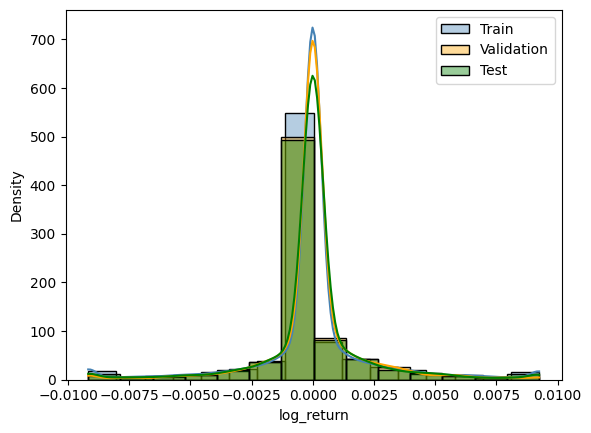

In [ ]:
# Comparamos las distribuciones de train/validation/test
def statistical_tests(col):
    ks_train_val = ks_2samp(df_train[col], df_validation[col])
    ks_train_test = ks_2samp(df_train[col], df_test[col])
    ks_val_test  = ks_2samp(df_validation[col], df_test[col])
    
    anova = f_oneway(df_train[col], df_validation[col], df_test[col])
    lev   = levene(df_train[col], df_validation[col], df_test[col])
    
    print(f"Kolmogorov–Smirnov p-values ({col}):")
    print(f"  Train vs Val : {ks_train_val.pvalue:.4f}")
    print(f"  Train vs Test: {ks_train_test.pvalue:.4f}")
    print(f"  Val  vs Test : {ks_val_test.pvalue:.4f}")
    print(f"ANOVA p-value : {anova.pvalue:.4f}")
    print(f"Levene p-value: {lev.pvalue:.4f}")

statistical_tests("log_return")

sns.histplot(df_train["log_return"], kde=True, stat="density", color="steelblue", alpha=0.4, label="Train")
sns.histplot(df_validation["log_return"],   kde=True, stat="density", color="orange",  alpha=0.4, label="Validation")
sns.histplot(df_test["log_return"],  kde=True, stat="density", color="green",   alpha=0.4, label="Test")
plt.legend()

In [ ]:
# media  y std de los conjuntos
variables = ["close", "log_volume"]
rows = []
for var in variables:
    row = {
        "Variable": var,
        "Media Train": df_train[var].mean(),
        "Media Val":   df_validation[var].mean(),
        "Media Test":  df_test[var].mean(),
        "σ Train":     df_train[var].std(),
        "σ Val":       df_validation[var].std(),
        "σ Test":      df_test[var].std()
    }
    rows.append(row)

summary_table = pd.DataFrame(rows)
summary_table = summary_table.round(6)
print(summary_table)

     Variable  Media Train   Media Val  Media Test    σ Train      σ Val  \
0       close   164.258978  309.615030  428.419943  42.199523  33.505601   
1  log_volume     6.047897    6.035928    6.017201   6.768789   6.784996   

      σ Test  
0  29.565002  
1   6.731080  


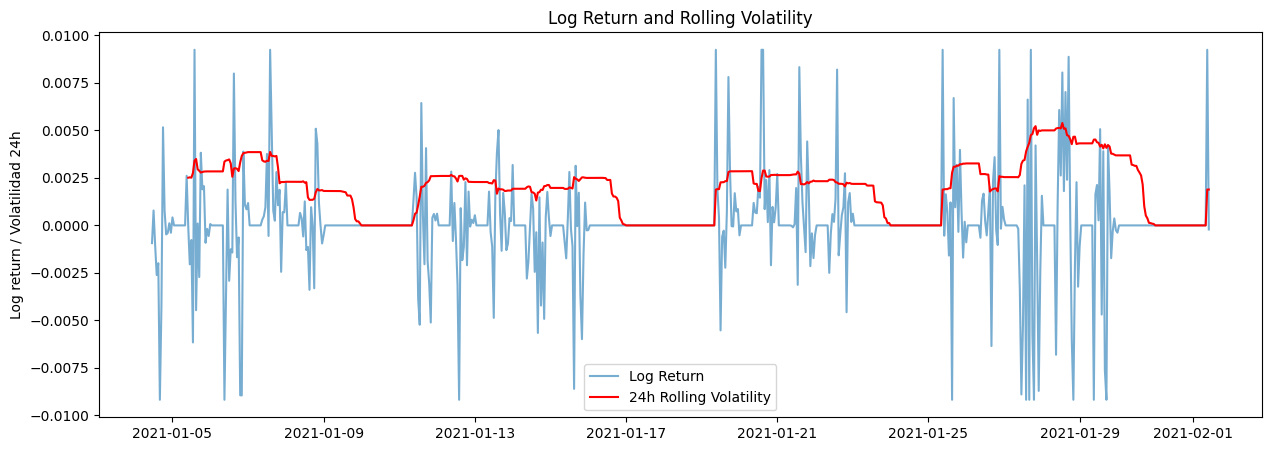

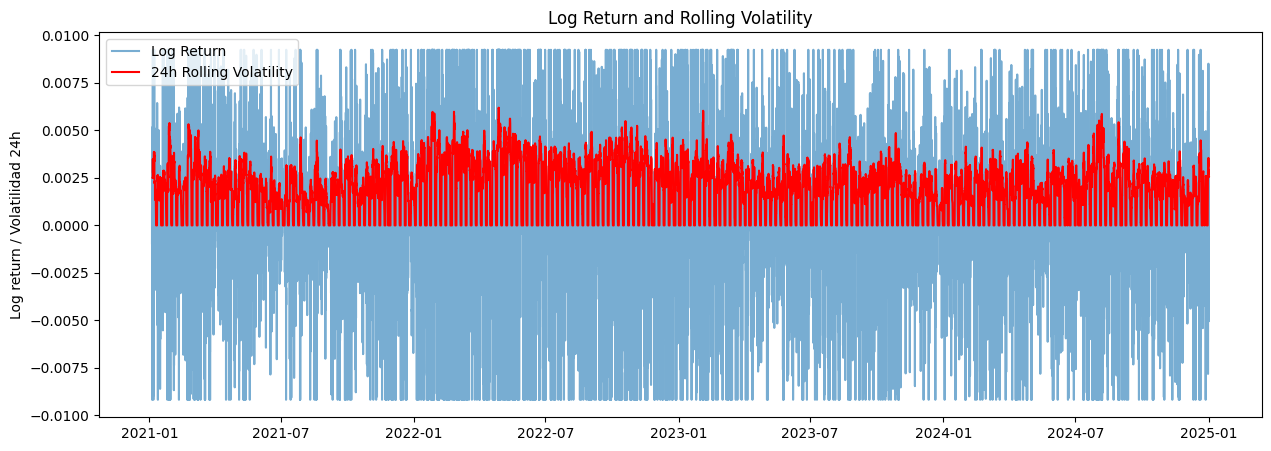

In [ ]:
# comparativo volumen, log-retuns
df_last = df[:24*7*4].copy()
df_last['rolling_vol'] = df_last['log_return'].rolling(window=24).std()

plt.figure(figsize=(15, 5))
plt.plot(df_last[DATETIME_COL],df_last['log_return'], label='Log Return', alpha=0.6)
plt.plot(df_last[DATETIME_COL],df_last['rolling_vol'], label='24h Rolling Volatility', color='red')
plt.legend()
plt.title("Log Return and Rolling Volatility")
plt.ylabel("Log return / Volatilidad 24h")
plt.show()

# dataset plot completo
df_all = df.copy()
df_all['rolling_vol'] = df_all['log_return'].rolling(window=24).std()

plt.figure(figsize=(15, 5))
plt.plot(df_all[DATETIME_COL],df_all['log_return'], label='Log Return', alpha=0.6)
plt.plot(df_all[DATETIME_COL],df_all['rolling_vol'], label='24h Rolling Volatility', color='red')
plt.legend()
plt.title("Log Return and Rolling Volatility")
plt.ylabel("Log return / Volatilidad 24h")
plt.show()



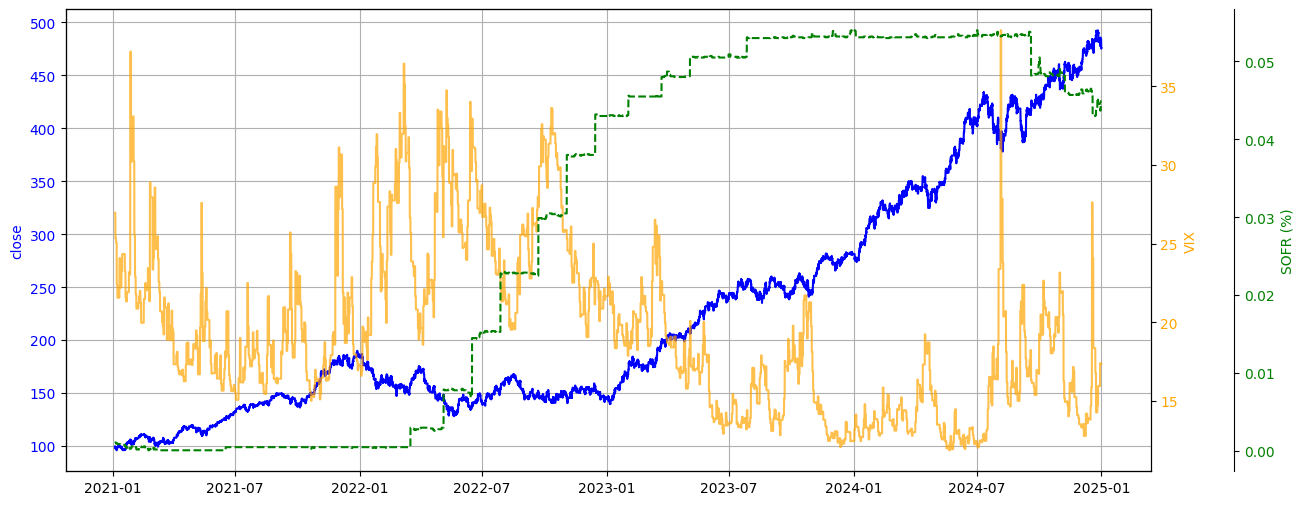

In [19]:
# Graficar con múltiples escalas
fig, ax1 = plt.subplots(figsize=(14, 6))

# Primer eje: Close
ax1.plot(df[DATETIME_COL], df['close'], color='blue', label='close')
ax1.set_ylabel('close', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

# Segundo eje: VIX
ax2 = ax1.twinx()
ax2.plot(df[DATETIME_COL], df['vix'], color='orange', label='VIX', alpha=0.7)
ax2.set_ylabel('VIX', color='orange')
ax2.tick_params(axis='y', labelcolor='orange')

# Tercer eje: SOFR
ax3 = ax1.twinx()
ax3.spines["right"].set_position(("outward", 60))  # Desplazar tercer eje
ax3.plot(df[DATETIME_COL], df['sofr'], color='green', label='SOFR', linestyle='--')
ax3.set_ylabel('SOFR (%)', color='green')
ax3.tick_params(axis='y', labelcolor='green')

# Título y cuadrícula
#plt.title(" close / VIX / SOFR", fontsize=14)
ax1.grid(True)

In [20]:
import ruptures as rpt
from matplotlib.dates import DateFormatter, AutoDateLocator

if False:
    series = df['log_return'].dropna()
    signal = series.values
    model = "normal" 
    algo = rpt.Pelt(model=model).fit(signal)
    result = algo.predict(pen=200)  # lista de índices de ruptura
    print(result)
    for index in result[:-1]:
        print(df.iloc[index][DATETIME_COL])
    # plot
    
    # change_dates ya calculado
    change_dates = series.index[result[:-1]]   # omitimos el último (final de la serie)
    
    # Figura
    fig, ax1 = plt.subplots(figsize=(12, 5))
    
    # Eje 1: Log Return
    ax1.plot(series.index, series, color="steelblue", label="Log Return")
    ax1.set_ylabel("Log Return", color="steelblue")
    ax1.tick_params(axis="y", labelcolor="steelblue")
    
    # Marcar rupturas
    for dt in change_dates:
        ax1.axvline(dt, color='red', linestyle='--', lw=1, label='_nolegend_')
    
    # Eje 2: Precio
    ax2 = ax1.twinx()
    ax2.plot(df.index, df["close"], color="blue", alpha=0.7, label="close")
    ax2.set_ylabel("Precio", color="blue")
    ax2.tick_params(axis="y", labelcolor="blue")
    
    # Formato del eje X (fechas)
    locator = AutoDateLocator()
    formatter = DateFormatter("%Y-%m")
    ax1.xaxis.set_major_locator(locator)
    ax1.xaxis.set_major_formatter(formatter)
    plt.xticks(rotation=45)
    
    # Título y leyendas
    ax1.set_title("Detección de changepoints en log_return y evolución del precio")
    
    # Combinar leyendas de ambos ejes
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")
    
    plt.tight_layout()
    plt.show()

C:\Users\MarcDelosPoch\AppData\Local\Temp\ipykernel_11148\331559980.py:18: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
D:\Reps\master-ia\10.- Trabajo fin de master\scripts\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


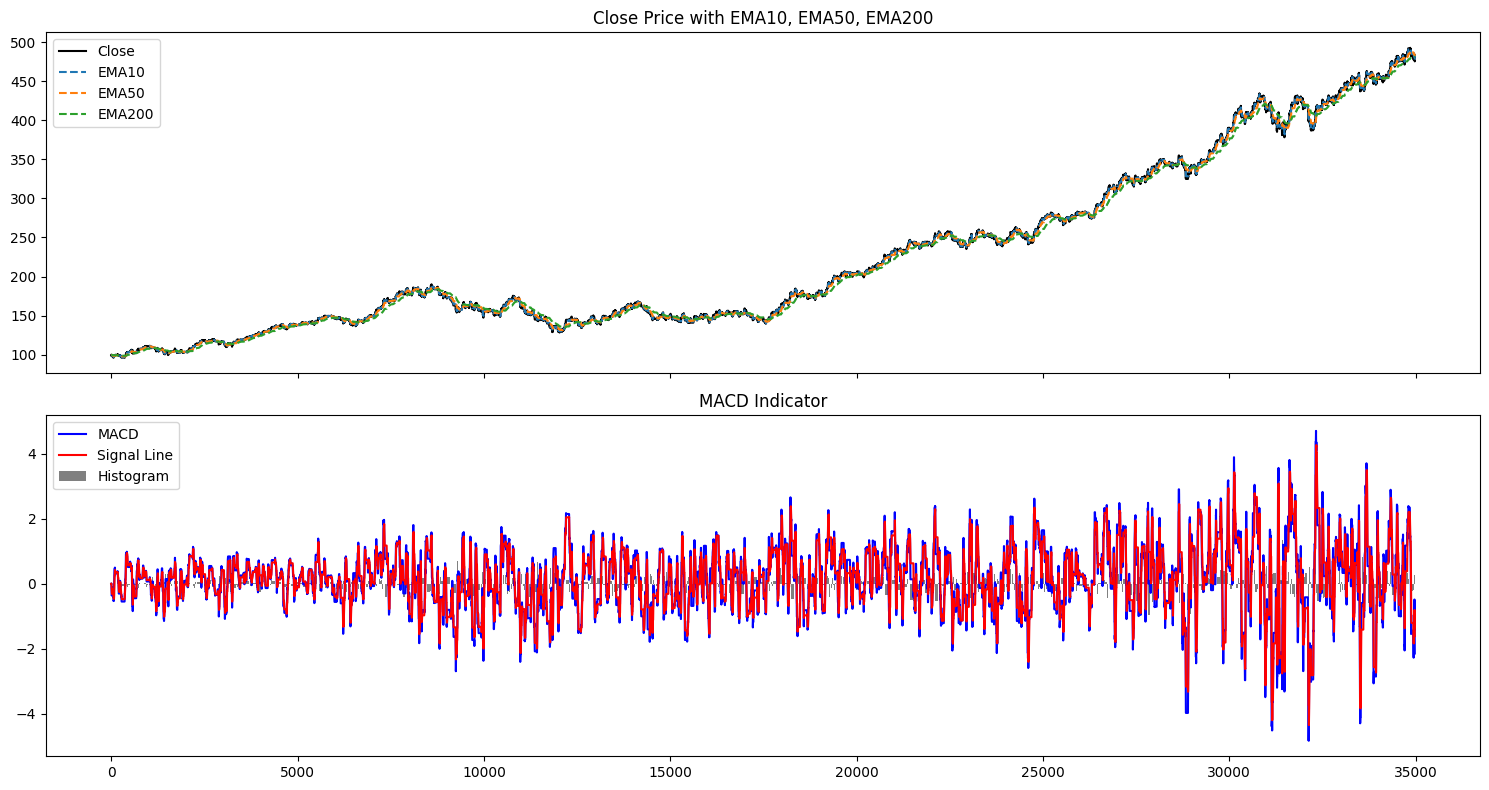

In [21]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 8), sharex=True)

# Price + EMAs
ax1.plot(df.index, df['close'], label='Close', color='black')
ax1.plot(df.index, df['ema10'], label='EMA10', linestyle='--')
ax1.plot(df.index, df['ema50'], label='EMA50', linestyle='--')
ax1.plot(df.index, df['ema200'], label='EMA200', linestyle='--')
ax1.set_title("Close Price with EMA10, EMA50, EMA200")
ax1.legend()

# MACD
ax2.plot(df.index, df['macd'], label='MACD', color='blue')
ax2.plot(df.index, df['macd_signal'], label='Signal Line', color='red')
ax2.bar(df.index, df['macd_histogram'], label='Histogram', color='gray')
ax2.set_title("MACD Indicator")
ax2.legend()

plt.tight_layout()
plt.show()


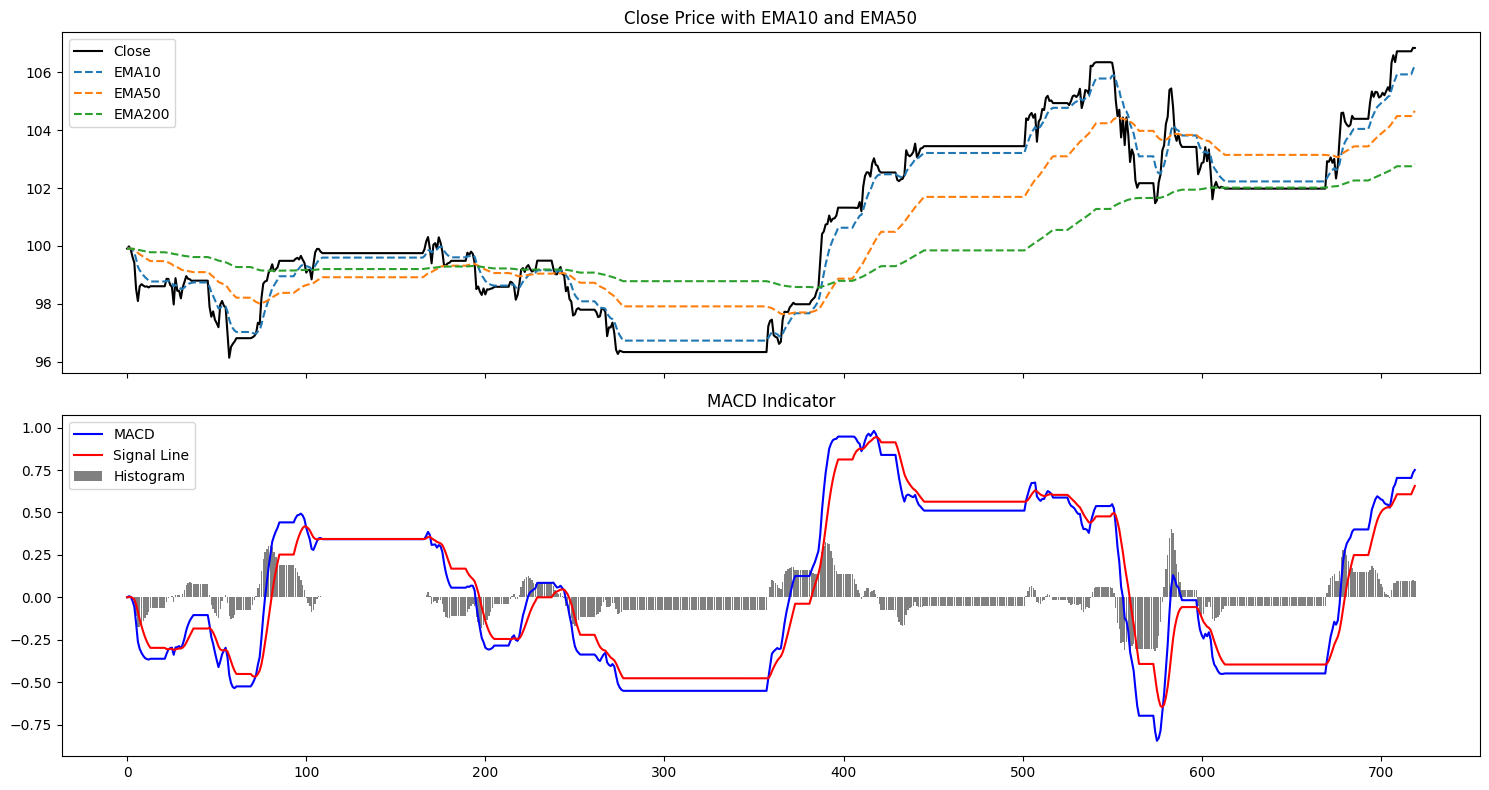

In [22]:
df_subset = df[:24*30*1]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 8), sharex=True)

# Price + EMAs
ax1.plot(df_subset.index, df_subset['close'], label='Close', color='black')
ax1.plot(df_subset.index, df_subset['ema10'], label='EMA10', linestyle='--')
ax1.plot(df_subset.index, df_subset['ema50'], label='EMA50', linestyle='--')
ax1.plot(df_subset.index, df_subset['ema200'], label='EMA200', linestyle='--')
ax1.set_title("Close Price with EMA10 and EMA50")
ax1.legend()

# MACD
ax2.plot(df_subset.index, df_subset['macd'], label='MACD', color='blue')
ax2.plot(df_subset.index, df_subset['macd_signal'], label='Signal Line', color='red')
ax2.bar(df_subset.index, df_subset['macd_histogram'], label='Histogram', color='gray')
ax2.set_title("MACD Indicator")
ax2.legend()

plt.tight_layout()
plt.show()

<Axes: >

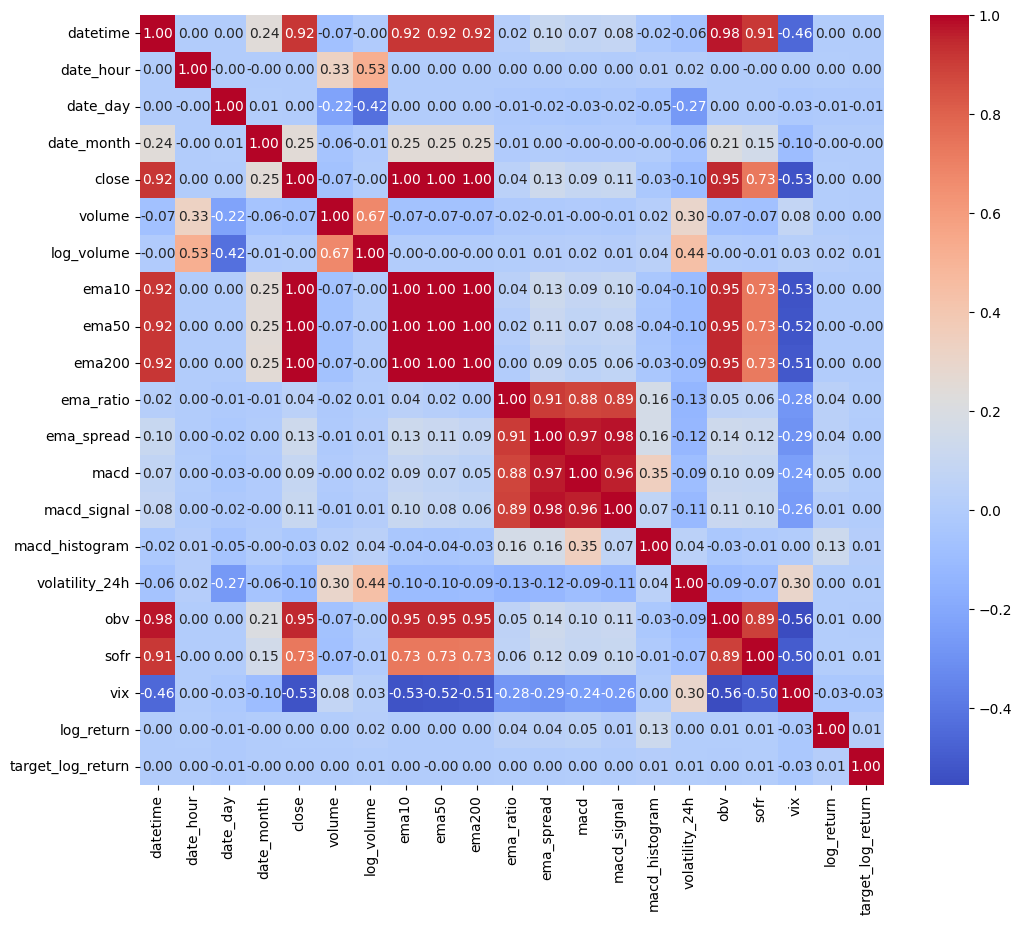

In [ ]:
# Matriza de correlación, para buscar features correlacionadas
plt.figure(figsize=(12, 10))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm')


<Axes: >

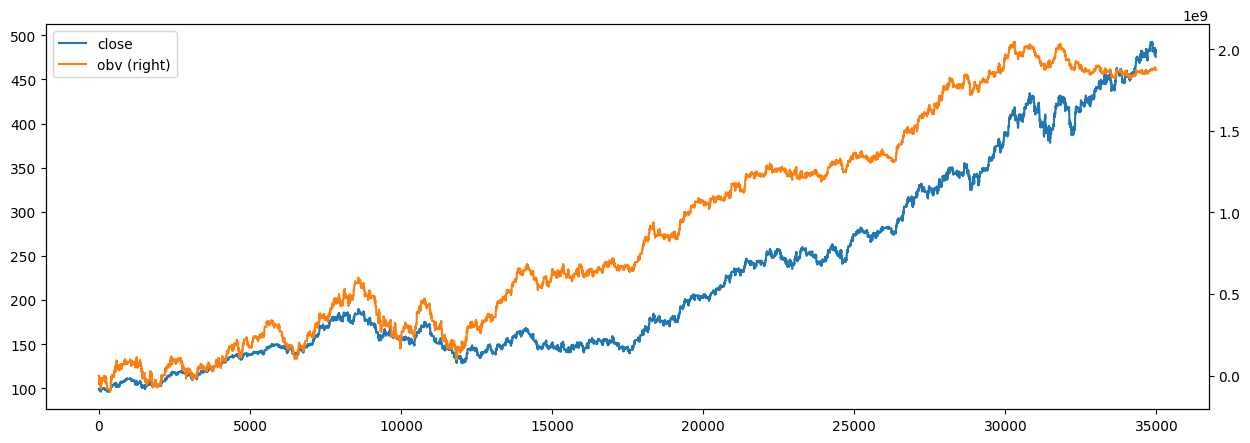

In [ ]:
# OBV analisys
df[['close', 'obv']].plot(secondary_y='obv', figsize=(15, 5))
# como hemos visto, el OBV está muy correlacionado con el CLOSE


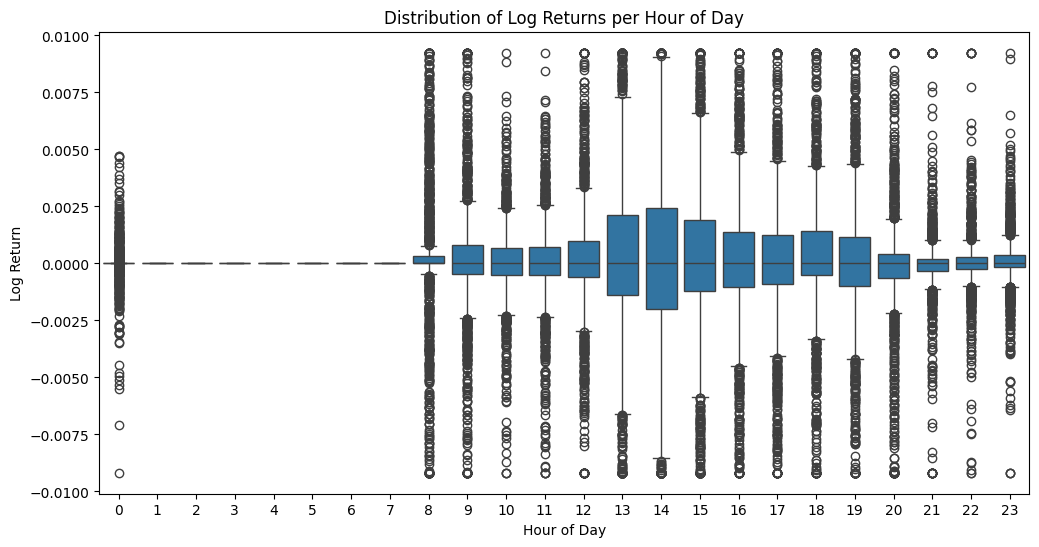

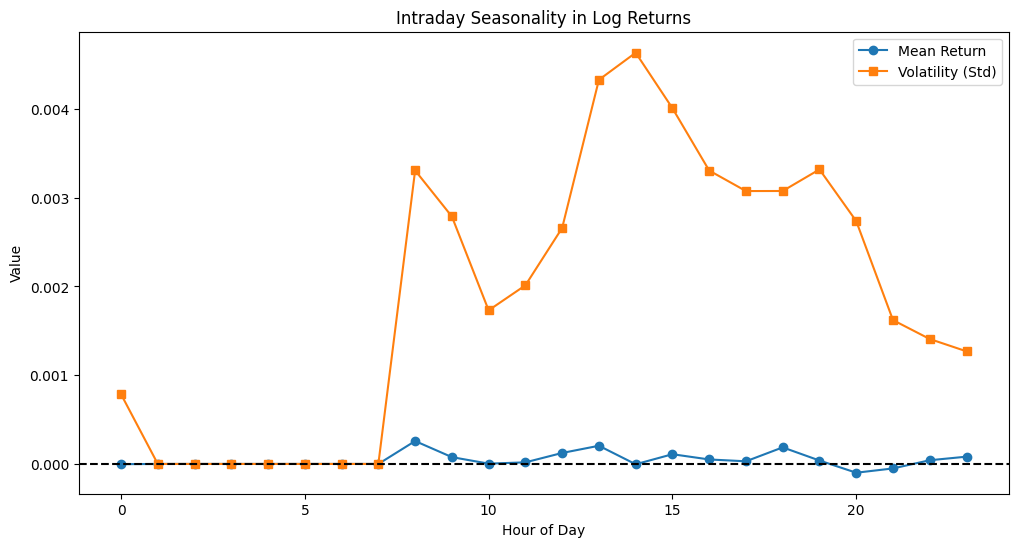

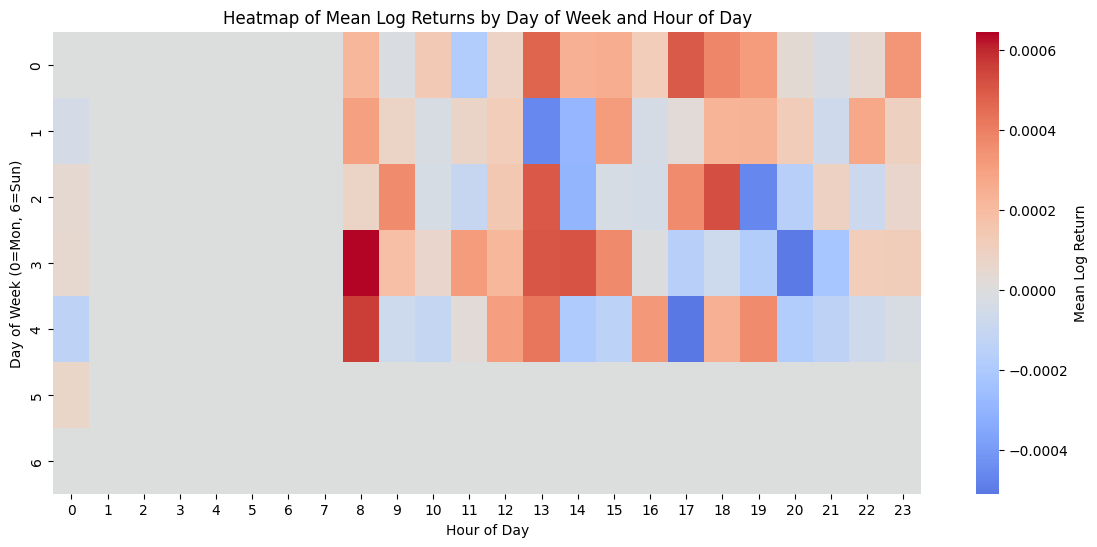

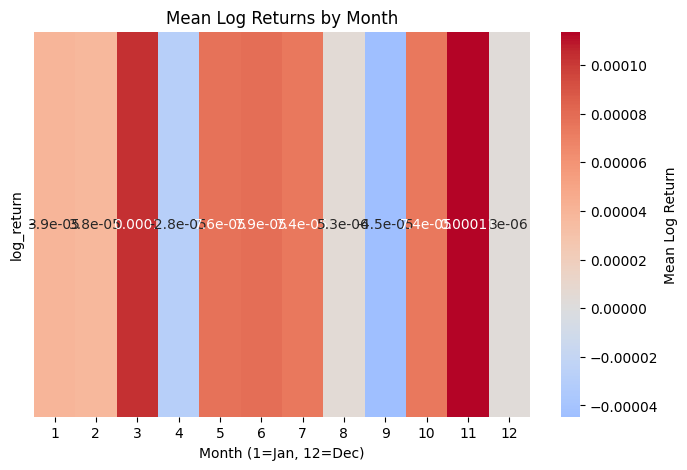

In [ ]:

# analizar intraday seasonality

# agrupar log_return por hora del dia
hourly_stats = df.groupby('date_hour')['log_return'].agg(['mean', 'std', 'count'])

plt.figure(figsize=(12,6))
sns.boxplot(x='date_hour', y='log_return', data=df)
plt.title("Distribution of Log Returns per Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Log Return")
plt.show()

plt.figure(figsize=(12,6))
plt.plot(hourly_stats.index, hourly_stats['mean'], marker='o', label='Mean Return')
plt.plot(hourly_stats.index, hourly_stats['std'], marker='s', label='Volatility (Std)')
plt.axhline(0, color='black', linestyle='--')
plt.title("Intraday Seasonality in Log Returns")
plt.xlabel("Hour of Day")
plt.ylabel("Value")
plt.legend()
plt.show()

# Extract day of week and hour of day
dt_heatmap = df.copy()

# Compute mean log return by (day, hour)
heatmap_data = dt_heatmap.pivot_table(
    index='date_day',
    columns='date_hour',
    values='log_return',
    aggfunc='mean'
)

# Plot heatmap
plt.figure(figsize=(14, 6))
sns.heatmap(heatmap_data, cmap="coolwarm", center=0, annot=False, cbar_kws={'label': 'Mean Log Return'})
plt.title("Heatmap of Mean Log Returns by Day of Week and Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Day of Week (0=Mon, 6=Sun)")
plt.show()

monthly_returns = df.groupby('date_month')['log_return'].mean().to_frame()
plt.figure(figsize=(8, 5))
sns.heatmap(monthly_returns.T, cmap="coolwarm", center=0, annot=True, cbar_kws={'label': 'Mean Log Return'})
plt.title("Mean Log Returns by Month")
plt.ylabel("")
plt.xlabel("Month (1=Jan, 12=Dec)")
plt.show()

# explicacion:
# The analysis of mean log returns by month shows that returns remain very close to zero across all months, in line with the efficient market hypothesis. Nonetheless, modest seasonal differences can be observed: months such as March, July, and November tend to show slightly higher mean returns, while April and September are comparatively weaker. These findings echo well-documented seasonal effects in financial literature, such as the 'September effect' and end-of-year rallies, although the magnitudes in this dataset are small and unlikely to be economically significant."

In [26]:
# Analizamos FEATURE IMPORTANCE

# Method 1: correlation with target
target_corr = df.corr()['target_log_return'].sort_values(ascending=False)
print(target_corr)

# explication:
# in EDA, show only CORRELATION + MUTUAL INFORMATION

# explication:
# The correlation analysis between features and the prediction target (target_log_return) revealed that macd_histogram, log_return, sofr, log_volume, and volatility_24h had the strongest linear associations. This result aligns with financial intuition: momentum (MACD), past returns, macroeconomic conditions (SOFR), trading activity (log volume), and volatility are all known drivers of asset dynamics. Nevertheless, the correlations were relatively weak in absolute terms, which is consistent with the efficient market hypothesis, highlighting that individual features carry limited predictive power in isolation. This underlines the need for multivariate and nonlinear modeling approaches that can exploit interactions among features."

# explanation: Pros: Simple, quick. Cons: Only captures linear relationships.

target_log_return    1.000000
macd_histogram       0.013945
log_return           0.009836
volatility_24h       0.008328
log_volume           0.007682
sofr                 0.005764
macd                 0.004930
ema_ratio            0.003884
ema_spread           0.002767
datetime             0.002694
obv                  0.001823
date_hour            0.001214
macd_signal          0.001045
volume               0.000424
close                0.000133
ema200               0.000039
ema10                0.000019
ema50               -0.000039
date_month          -0.001193
date_day            -0.013087
vix                 -0.028500
Name: target_log_return, dtype: float64
